# Infer copy-number variation in plasma cells

**Biology rationale.** Copy-number profiles provide orthogonal evidence of clonal plasma-cell identity and allow assessment of genomic stability across treatment.

**Aim.** Infer chromosome-scale CNV patterns and compare CNV states across clonotypes and clinical groups.

**Data input.** `counts_clean.h5ad`, `genes.gtf`, `chr_pq.txt`, `cnv_arm_matrix.csv`, `cnv_arm_heatmap.pdf`



**Data outputs.** `cnv_arm_scores.csv`

## 1. Copy-number inference and visualization


In [1]:
import scanpy as sc
import infercnvpy as cnv
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter("ignore")

sc.settings.set_figure_params(figsize=(5, 5))


In [2]:
adata = sc.read_h5ad("counts_clean.h5ad") #used to be the plasma cell sample

In [3]:
cnv.io.genomic_position_from_gtf(gtf_file='genes.gtf', adata=adata ,   inplace=True)

INFO:root:Extracted GTF attributes: ['gene_id', 'gene_version', 'gene_type', 'gene_name', 'level', 'hgnc_id', 'tag', 'havana_gene', 'transcript_id', 'transcript_version', 'transcript_type', 'transcript_name', 'transcript_support_level', 'havana_transcript', 'exon_number', 'exon_id', 'exon_version', 'protein_id', 'ccdsid', 'ont']


In [4]:
# We provide all immune cell types as "normal cells".
cnv.tl.infercnv(
    adata,
    reference_key="clonotype",
    reference_cat=[
        "polyclonal"
    ],
    window_size=250,
)


  0%|          | 0/37 [00:00<?, ?it/s]

Demonstrate CNV distribution in all clonotypes

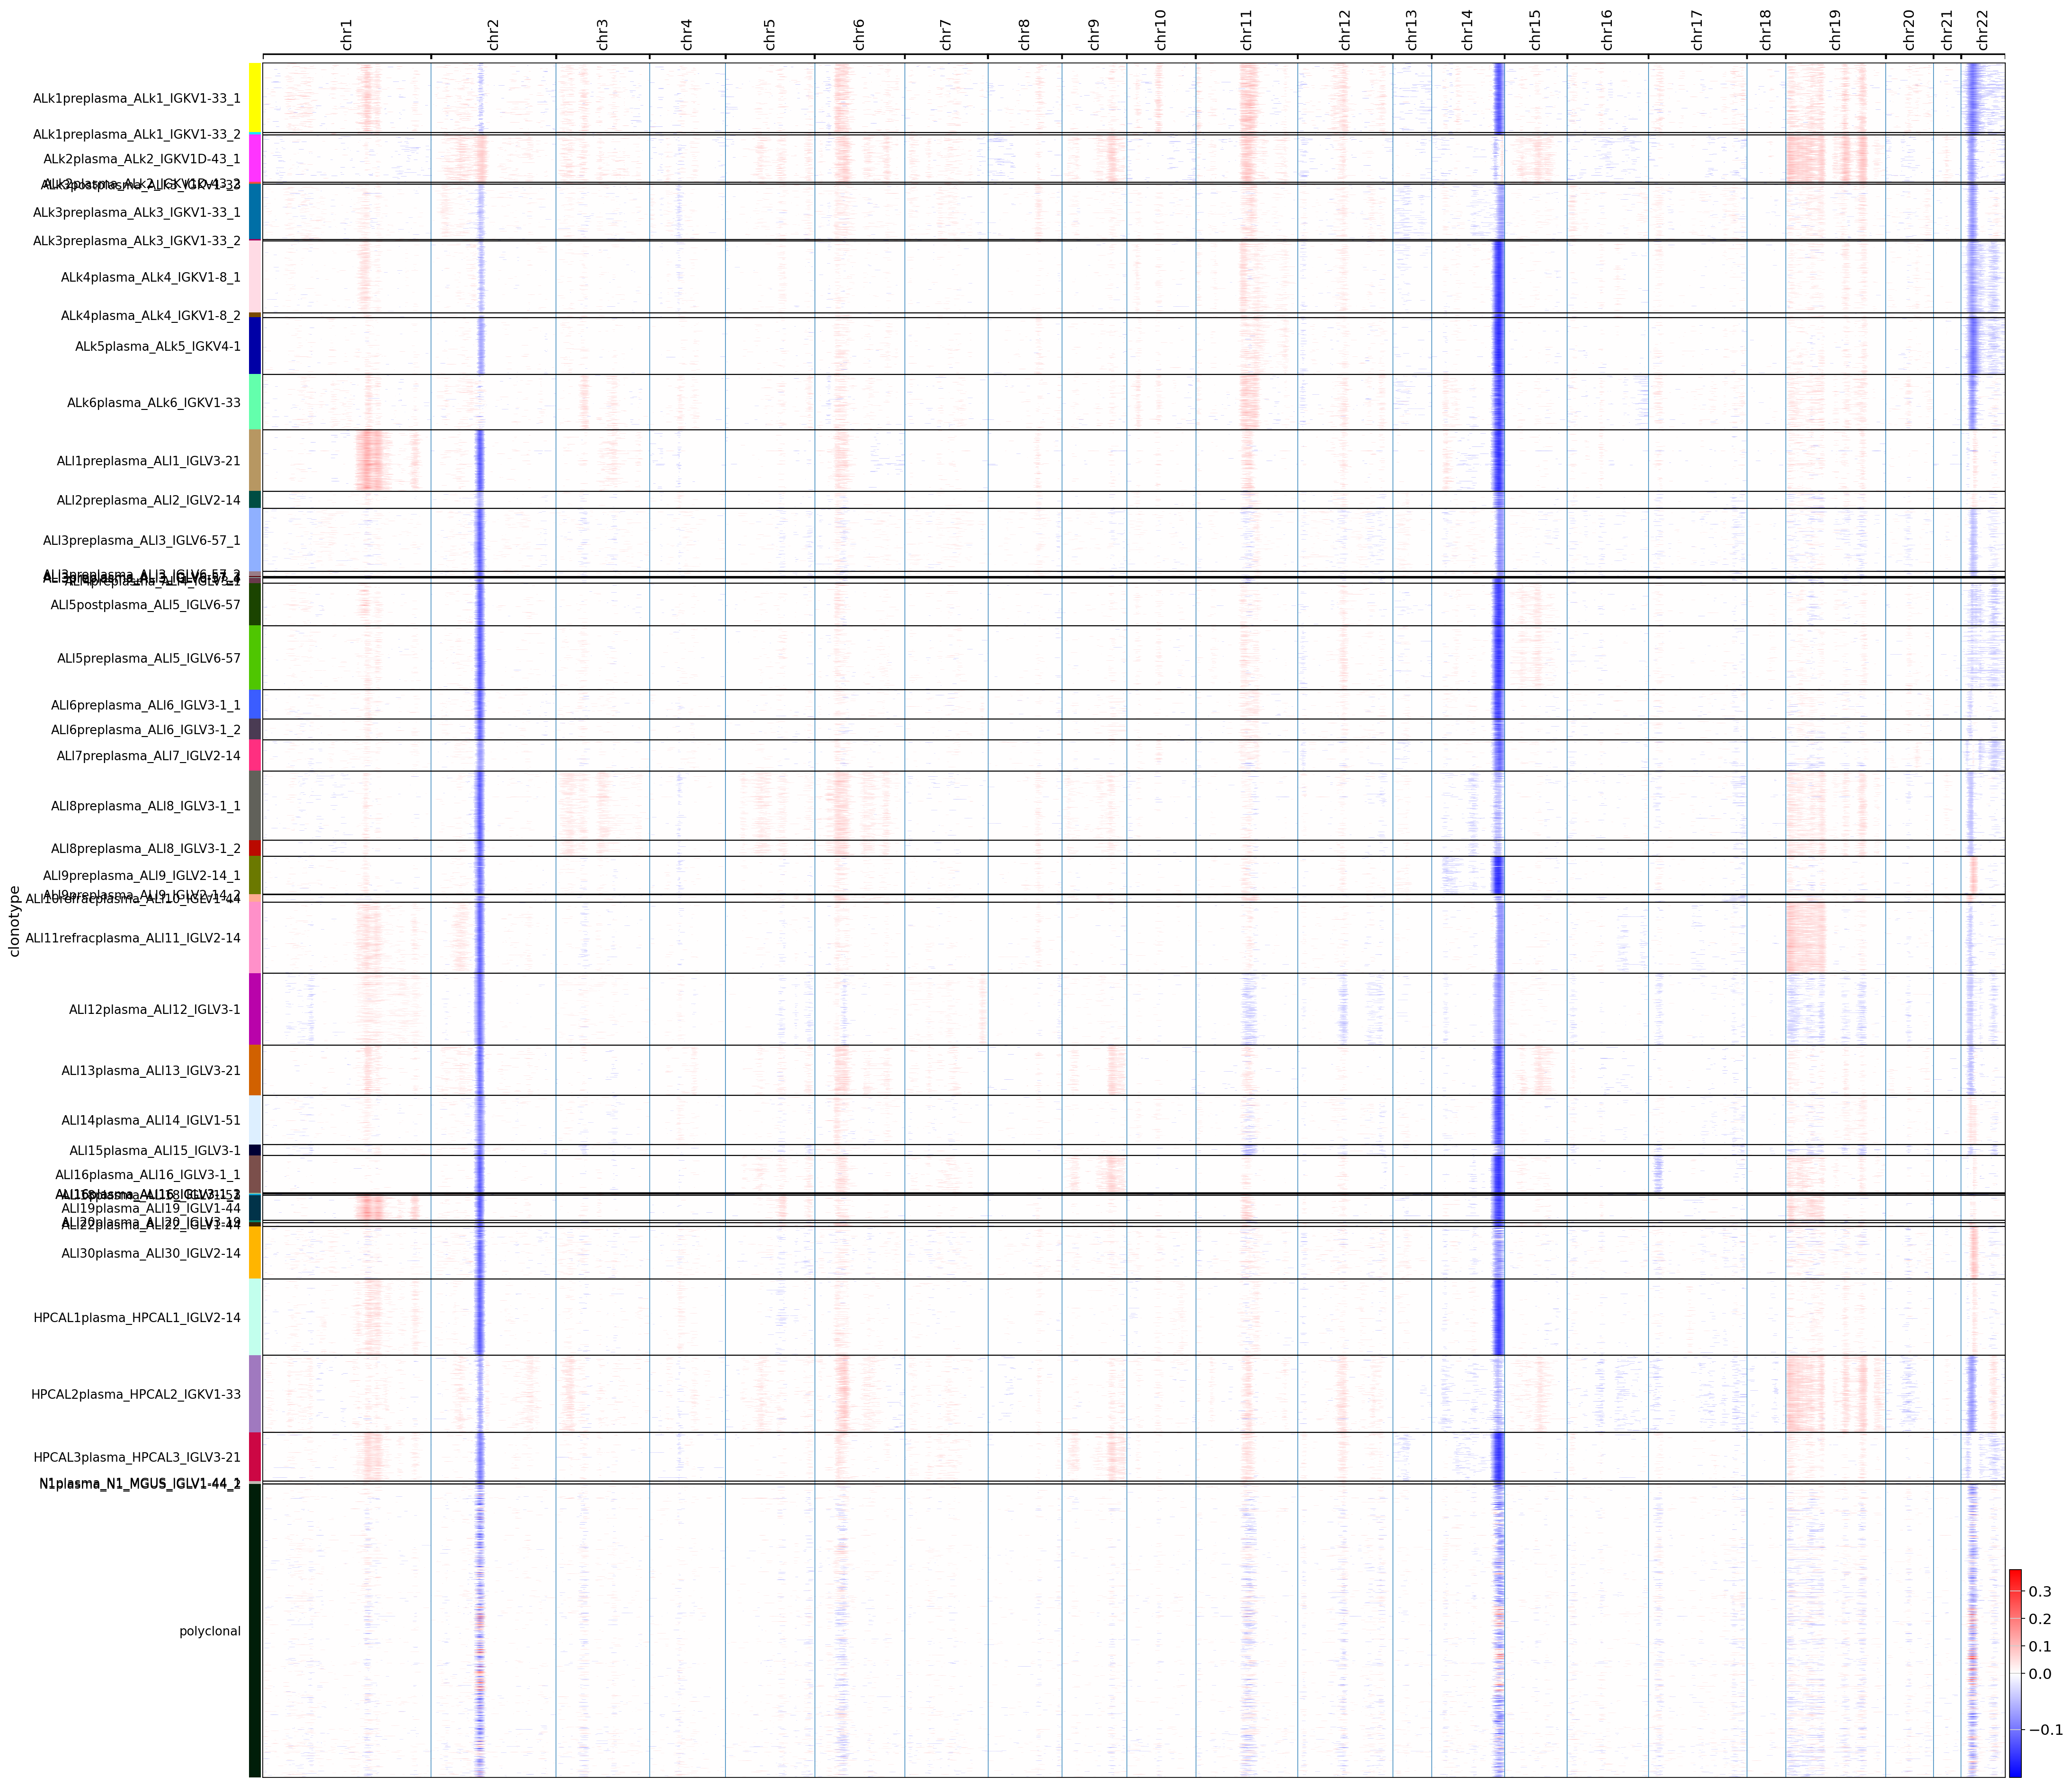

In [5]:
cnv.pl.chromosome_heatmap( adata, groupby="clonotype",figsize=(30, 30))


## 2. Copy-number inference and visualization


In [6]:
cnv.tl.pca(adata)
cnv.pp.neighbors(adata)
cnv.tl.leiden(adata)


         Falling back to preprocessing with `sc.pp.pca` and default params.
categories: 0, 1, 2, etc.
var_group_labels: chr1, chr2, chr3, etc.


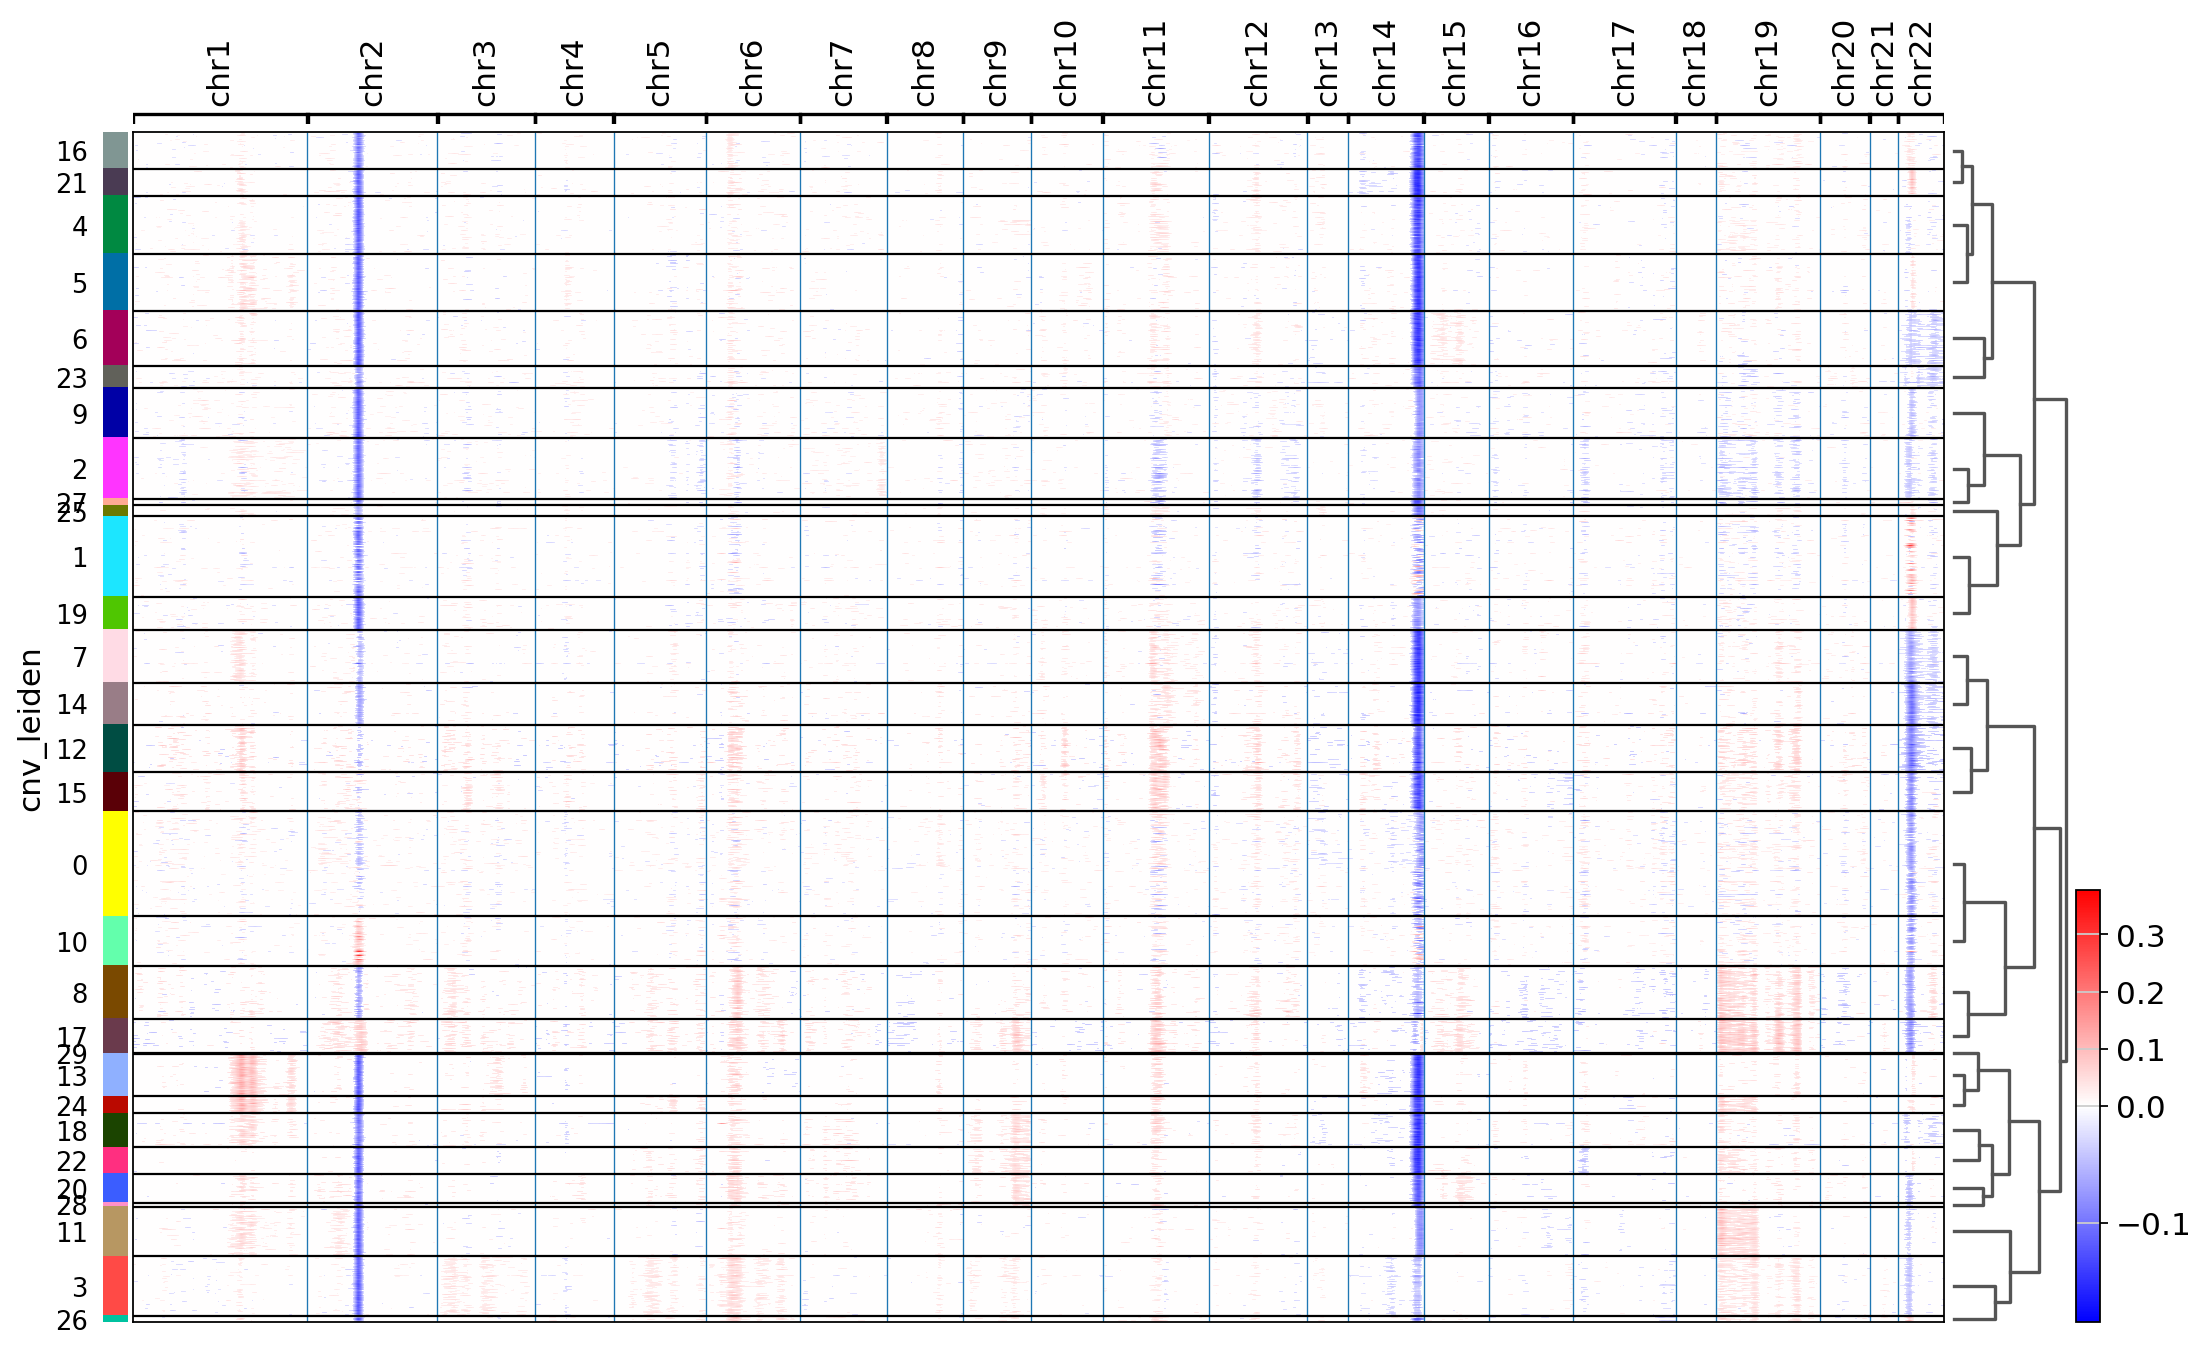

In [7]:
cnv.pl.chromosome_heatmap(adata, groupby="cnv_leiden", dendrogram=True)

In [8]:
cnv.tl.umap(adata)
cnv.tl.cnv_score(adata)

## 3. Visualization and figure generation


... storing 'gene_id' as categorical
... storing 'gene_name' as categorical


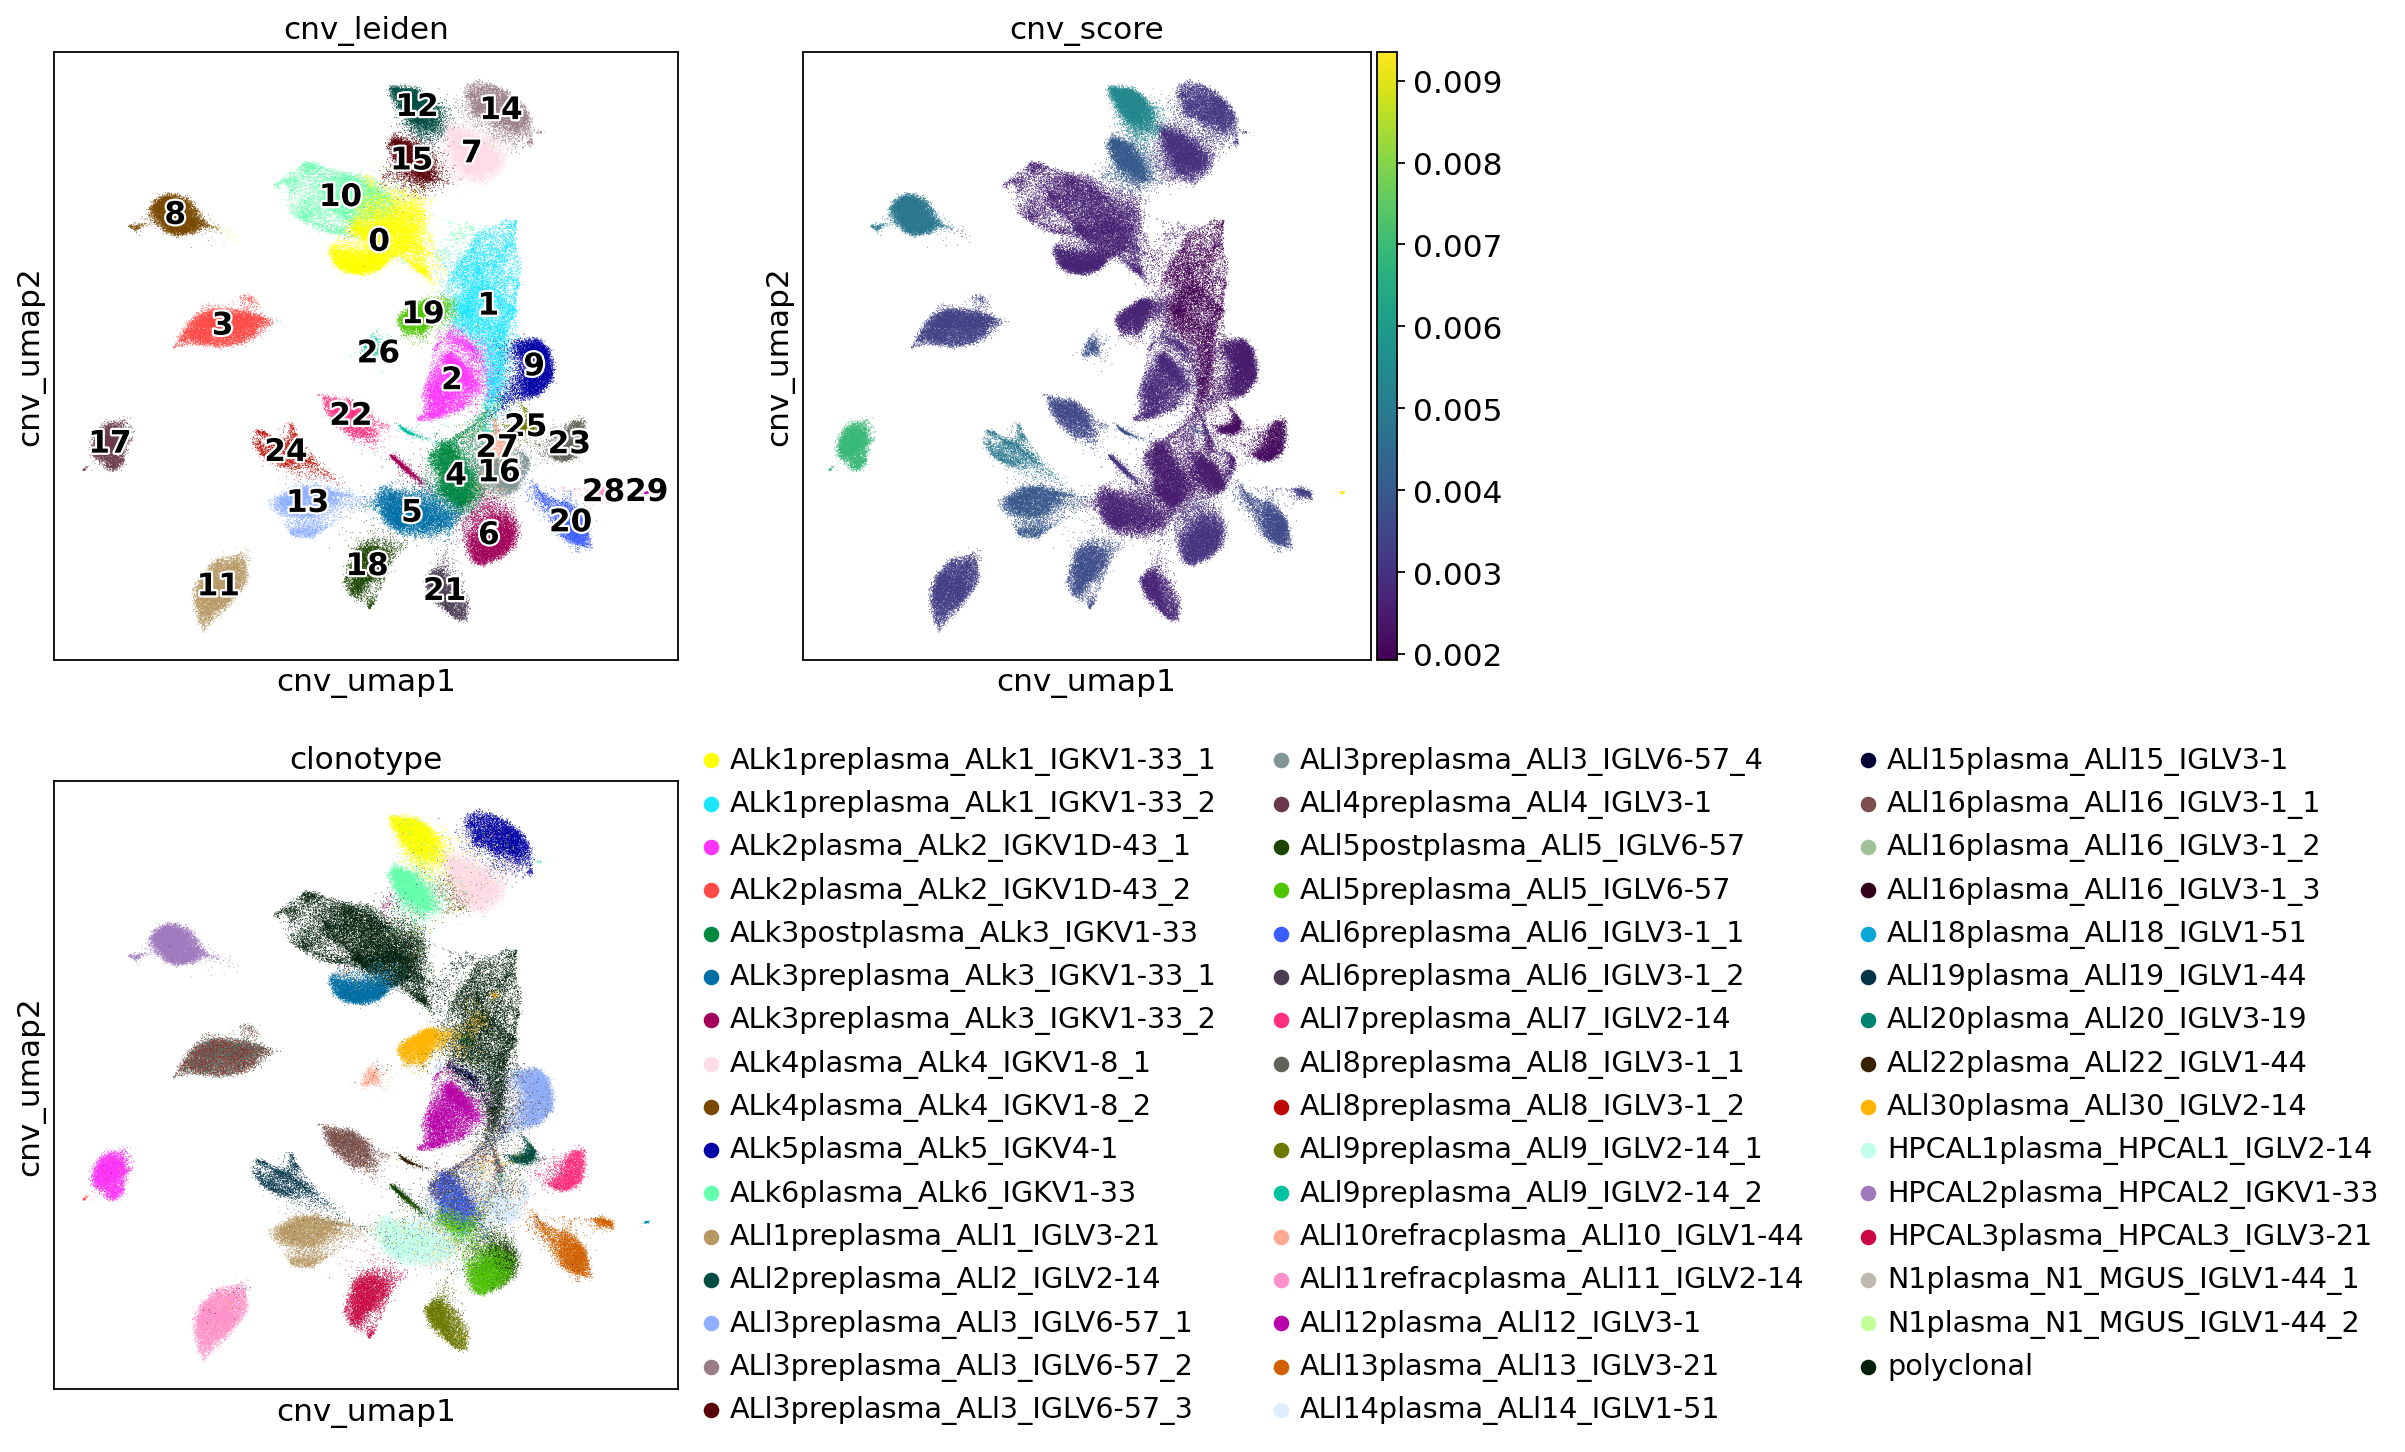

In [9]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 11))
ax4.axis("off")
cnv.pl.umap(
    adata,
    color="cnv_leiden",
    legend_loc="on data",
    legend_fontoutline=2,
    ax=ax1,
    show=False,
)
cnv.pl.umap(adata, color="cnv_score", ax=ax2, show=False)
cnv.pl.umap(adata, color="clonotype", ax=ax3)


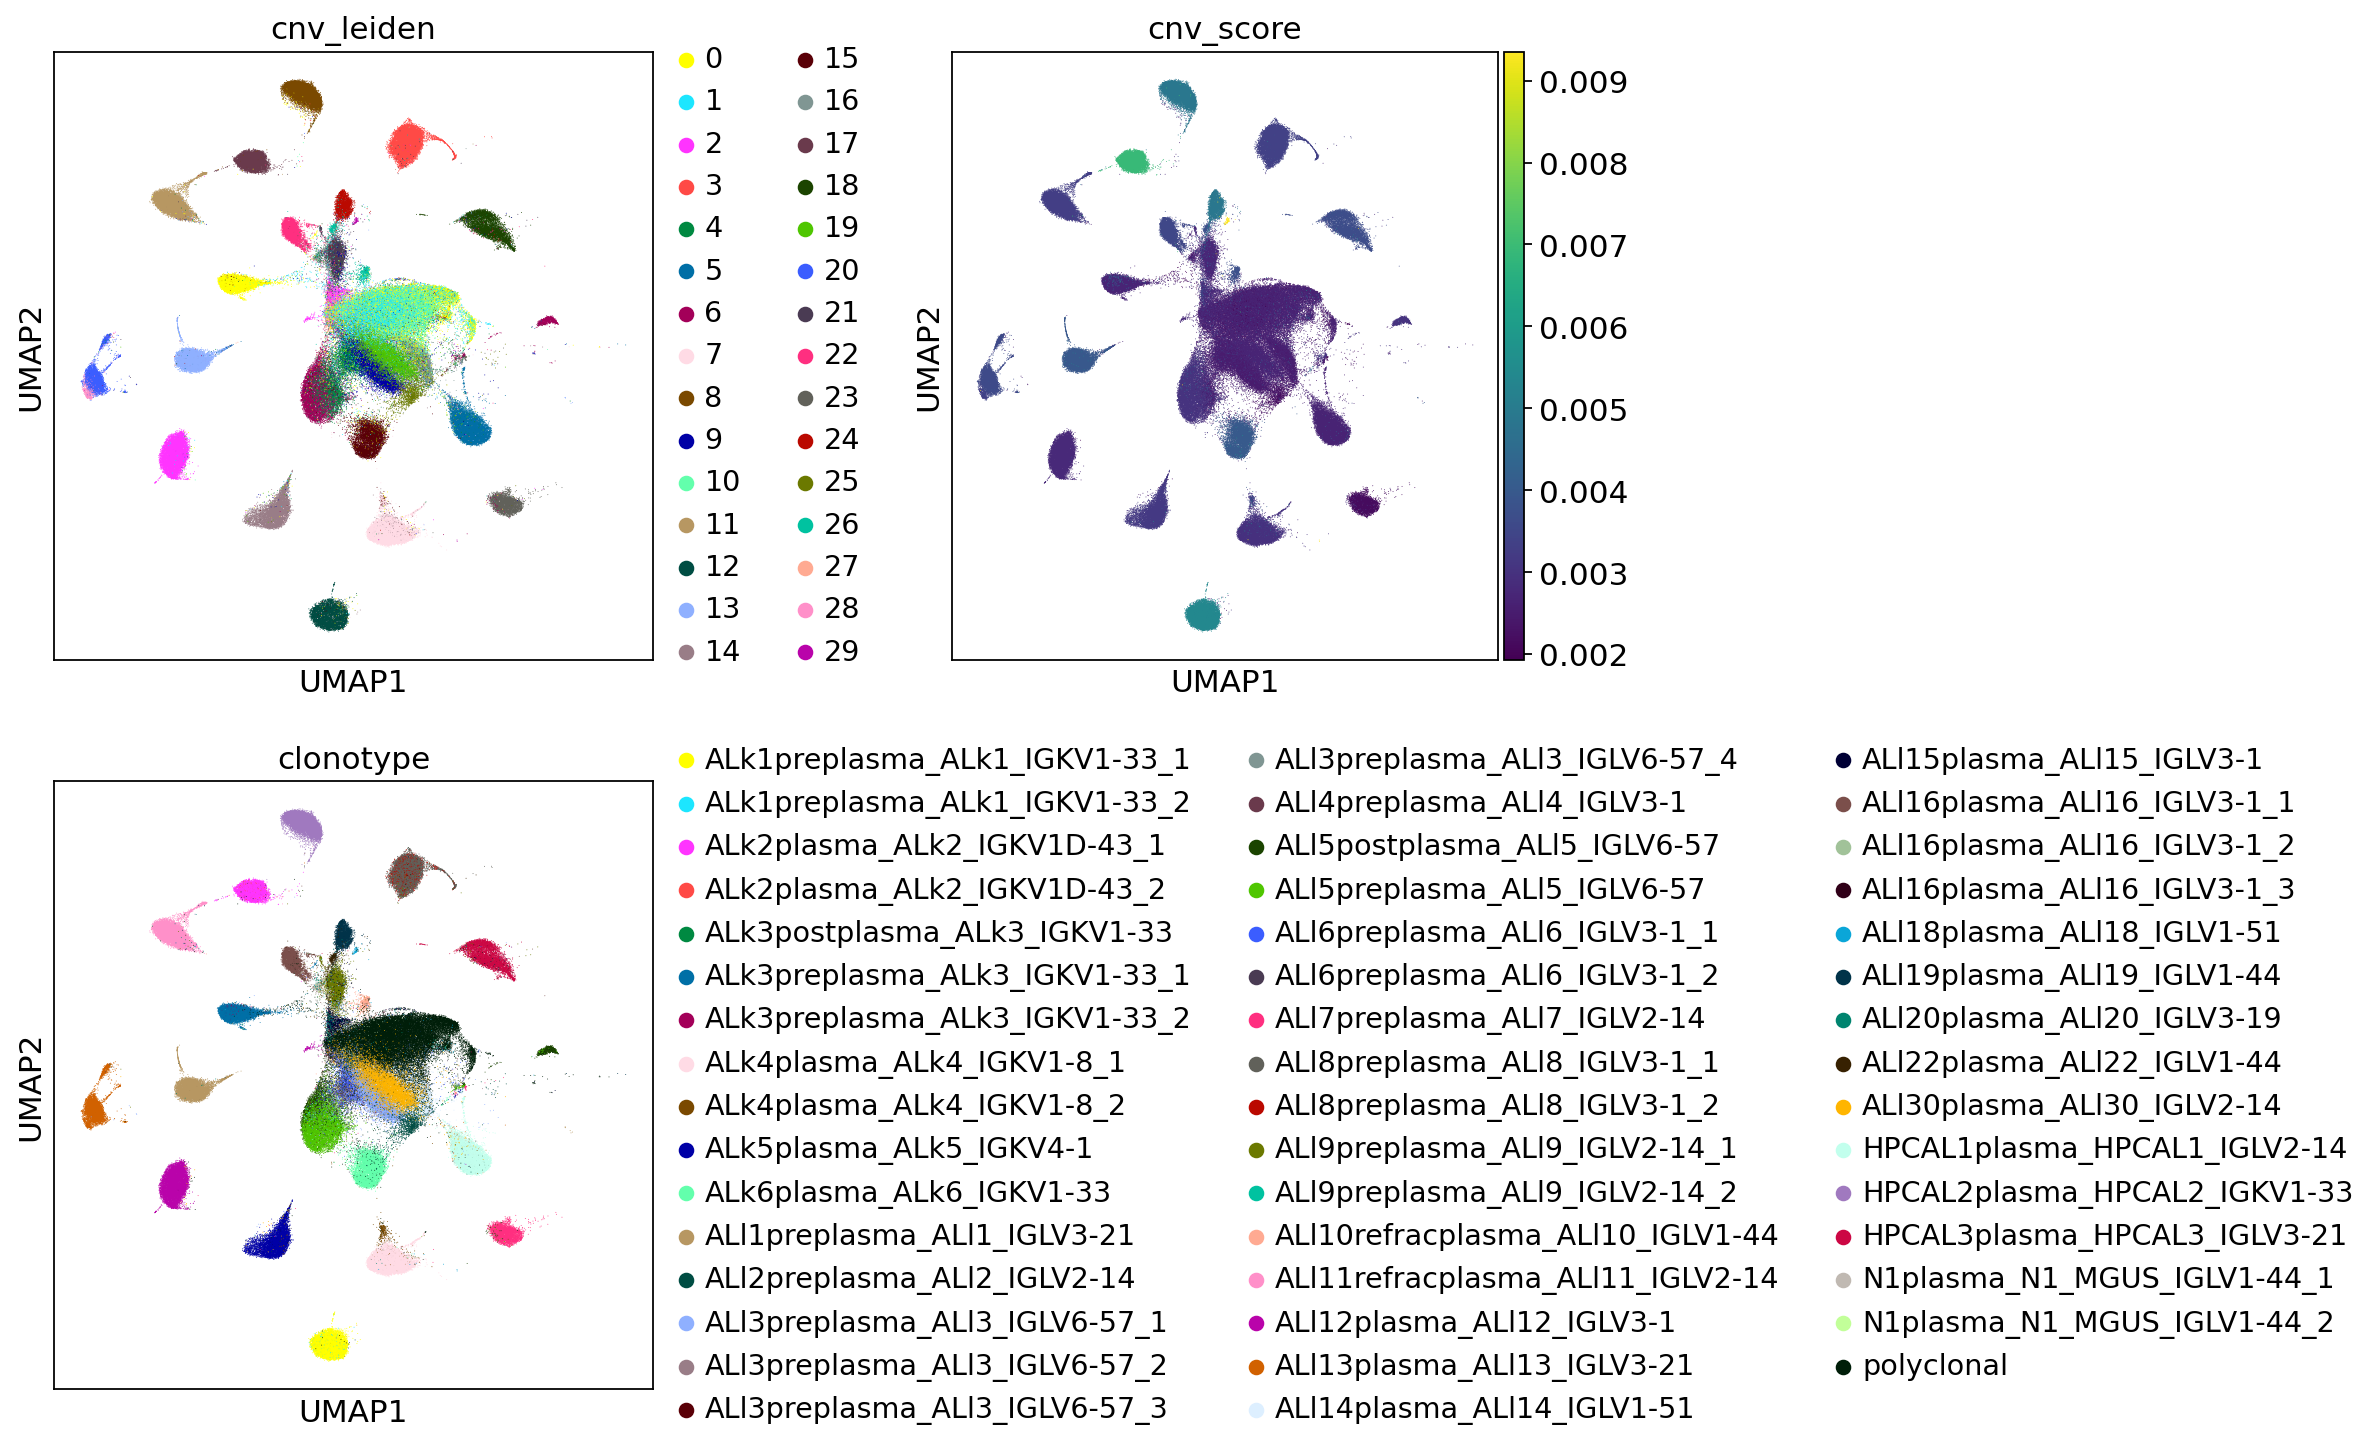

In [10]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 11), gridspec_kw={"wspace": 0.5})
ax4.axis("off")
sc.pl.umap(adata, color="cnv_leiden", ax=ax1, show=False)
sc.pl.umap(adata, color="cnv_score", ax=ax2, show=False)
sc.pl.umap(adata, color="clonotype", ax=ax3)

Aggregate CNV on the p/q arms of each chromosome

Saved tidy table: cnv_arm_scores.csv
Saved wide matrix: cnv_arm_matrix.csv


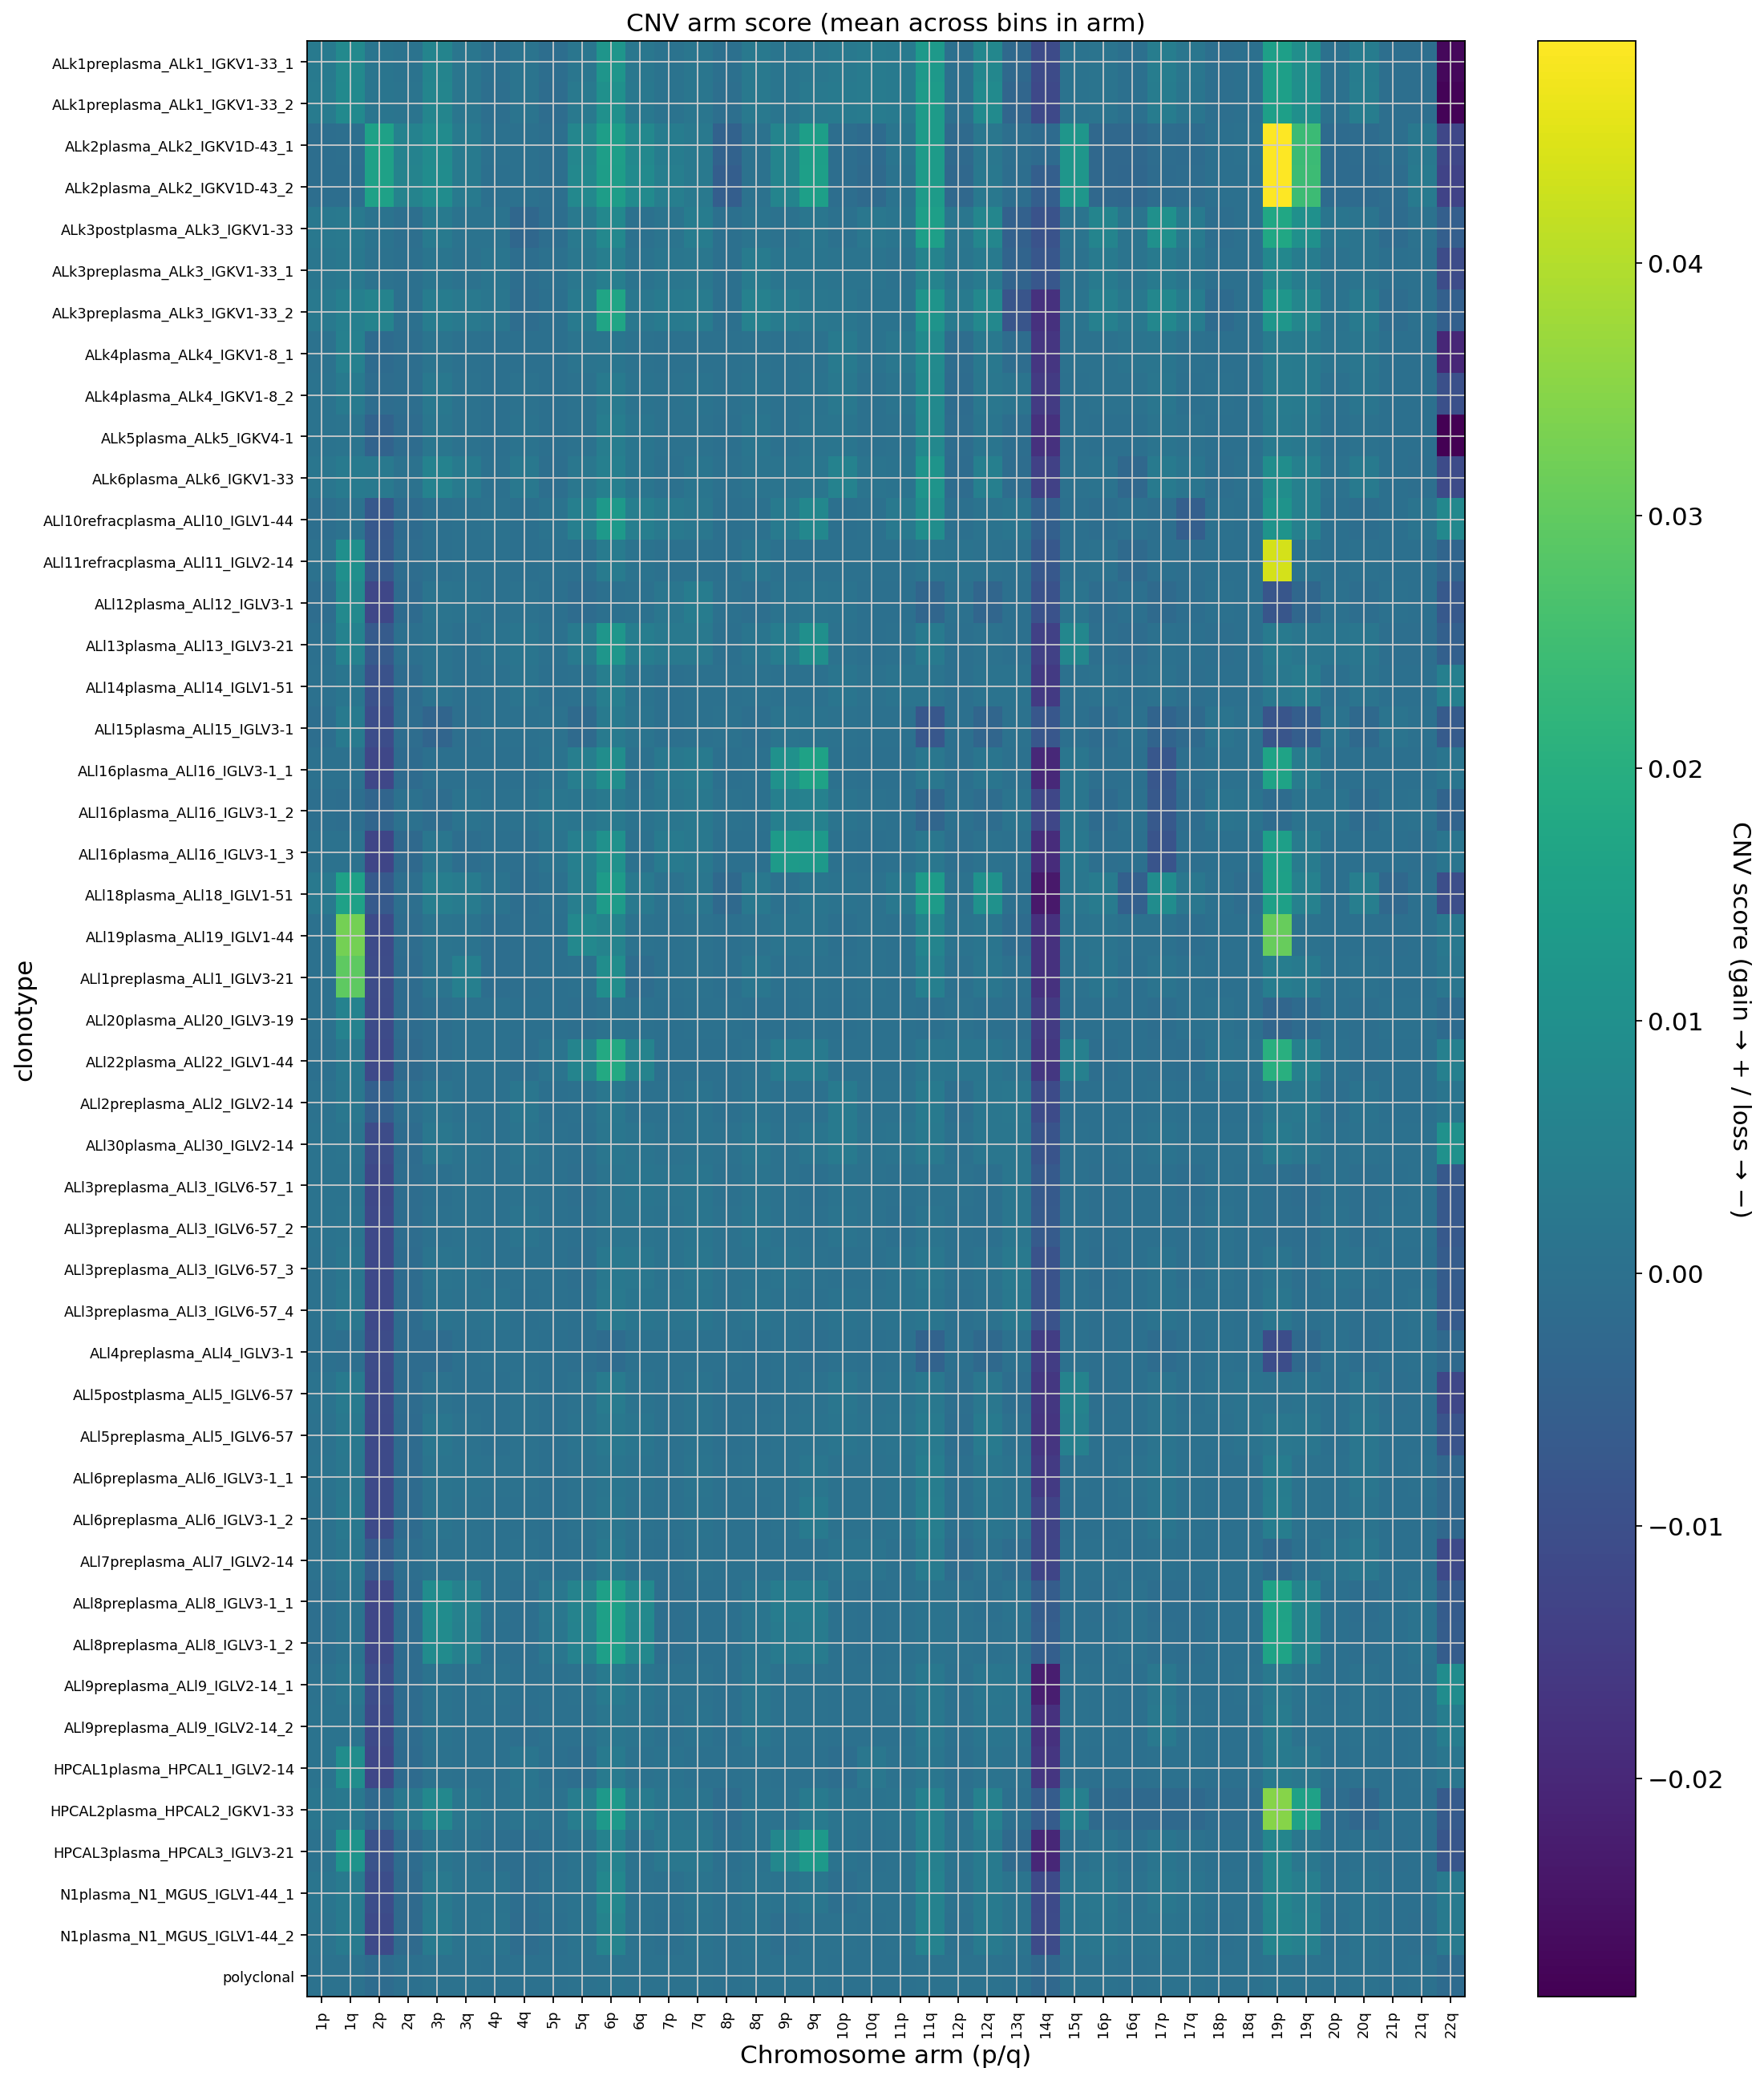

Saved heatmap: cnv_arm_heatmap.pdf


In [11]:
# --- imports
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

# ===========================
# Config (edit these)
# ===========================
CHR_PQ_PATH = "chr_pq.txt"          # p/q definitions with cutoff per chromosome
GROUP_KEY   = "clonotype"           # grouping column in adata.obs (e.g., 'cnv_leiden')
OUT_TABLE   = "cnv_arm_scores.csv"  # tidy table
OUT_WIDE    = "cnv_arm_matrix.csv"  # wide matrix (groups x arms)
OUT_FIG     = "cnv_arm_heatmap.pdf" # heatmap

# ===========================
# Helpers
# ===========================
def _ensure_chr_prefix_series(s: pd.Series) -> pd.Series:
    s = s.astype(str)
    return s.where(s.str.startswith("chr"), "chr" + s)

def _chr_rank(c):
    c = str(c).replace("chr", "")
    try:
        return int(c)
    except ValueError:
        return {"X":23,"Y":24,"M":25,"MT":25}.get(c.upper(), 999)

def arm_sort_key(a: str):
    base, suf = a[:-1], a[-1]
    try: num = int(base)
    except ValueError:
        num = {"X":23,"Y":24,"M":25,"MT":25}.get(base.upper(), 999)
    return (num, 0 if suf=="p" else 1)

def assign_arm_by_cutoff(df: pd.DataFrame, chr_pq: pd.DataFrame, pos_col: str = "center") -> pd.Series:
    """
    df        : DataFrame with columns ['chromosome', pos_col] for bins
    chr_pq    : table with columns ['chr','cutoff'] (cutoff is genomic coordinate separating p/q)
    pos_col   : which coordinate to compare to cutoff (e.g., bin center)
    returns   : Series of '1p','1q','Xp','Xq' or None per bin
    """
    x = df.copy()
    x["chromosome"] = _ensure_chr_prefix_series(x["chromosome"])
    chr_pq = chr_pq.copy()
    chr_pq["chr"] = _ensure_chr_prefix_series(chr_pq["chr"])
    cutoff_map = dict(zip(chr_pq["chr"], pd.to_numeric(chr_pq["cutoff"], errors="coerce")))

    pos  = pd.to_numeric(x[pos_col], errors="coerce").values
    chrs = x["chromosome"].astype(str).values
    out = []
    for c, p in zip(chrs, pos):
        co = cutoff_map.get(c, np.nan)
        if np.isnan(co) or np.isnan(p):
            out.append(None)
        else:
            out.append(f"{c.replace('chr','')}{'p' if p <= co else 'q'}")
    return pd.Series(out, index=x.index, name="arm")

def build_bins_df(adata) -> pd.DataFrame:
    """
    Return a DataFrame describing each CNV bin in X_cnv:
    index: bin index [0..n_bins-1]
    columns: ['chromosome','start','end','center']
    Tries several infercnvpy layouts; falls back to reconstructing from genes per bin.
    """
    if "X_cnv" not in adata.obsm:
        raise ValueError("adata.obsm['X_cnv'] not found.")
    n_bins = adata.obsm["X_cnv"].shape[1]
    cnv_uns = adata.uns.get("cnv", {})

    # --- 1) Direct bin table present (most convenient) ---
    # Possibilities seen in the wild:
    # - cnv_uns['bins'] : DataFrame with chromosome/start/end
    # - cnv_uns['bin_table'] : same idea
    # - cnv_uns['bin_positions'] : dict or DataFrame
    for key in ["bins", "bin_table", "bin_positions"]:
        val = cnv_uns.get(key, None)
        if isinstance(val, pd.DataFrame) and {"chromosome","start","end"}.issubset(val.columns):
            df = val.copy()
            if len(df) != n_bins:
                # if extra cols/rows exist, try to align by an 'index' or 'bin' column
                if "bin" in df.columns:
                    df = df.sort_values("bin").iloc[:n_bins]
                else:
                    df = df.iloc[:n_bins]
            df = df.loc[:n_bins-1, ["chromosome","start","end"]].copy()
            df["chromosome"] = _ensure_chr_prefix_series(df["chromosome"])
            df["start"] = pd.to_numeric(df["start"], errors="coerce")
            df["end"]   = pd.to_numeric(df["end"],   errors="coerce")
            df["center"] = (df["start"] + df["end"]) / 2.0
            df.index = pd.Index(range(len(df)), name="bin")
            return df

    # --- 2) Bin-to-gene mapping present; derive coordinates from member genes ---
    # Possibilities:
    # - cnv_uns['bin_genes'] : list-of-lists or dict {bin_idx: [gene_names]}
    # - cnv_uns['bin_to_varidx'] : list-of-lists of var indices
    for key in ["bin_genes", "bin_to_varidx", "bin2genes", "bin_vars"]:
        val = cnv_uns.get(key, None)
        if val is not None:
            # normalize to list of var indices per bin
            if isinstance(val, dict):
                # keys could be str or int
                mapping = [val.get(i, val.get(str(i), [])) for i in range(n_bins)]
                # If mapping contains gene names, convert to var idx
                if len(mapping) and isinstance(mapping[0], list) and len(mapping[0]) and not np.issubdtype(type(mapping[0][0]), np.integer):
                    # convert names -> index
                    name_to_idx = pd.Series(range(adata.n_vars), index=adata.var_names.astype(str)).to_dict()
                    mapping = [[name_to_idx[g] for g in genes if g in name_to_idx] for genes in mapping]
            elif isinstance(val, (list, tuple)):
                mapping = list(val)
            else:
                mapping = [[] for _ in range(n_bins)]

            var = adata.var.copy()
            var["chromosome"] = _ensure_chr_prefix_series(var.get("chromosome", pd.Series(index=var.index, dtype=str)).fillna(""))
            var["start"] = pd.to_numeric(var.get("start", pd.Series(index=var.index, dtype=float)), errors="coerce")
            var["end"]   = pd.to_numeric(var.get("end",   pd.Series(index=var.index, dtype=float)), errors="coerce")

            rows = []
            for i in range(n_bins):
                idxs = mapping[i] if i < len(mapping) else []
                idxs = [j for j in idxs if (0 <= j < adata.n_vars)]
                if not idxs:
                    rows.append({"chromosome": None, "start": np.nan, "end": np.nan})
                    continue
                sub = var.iloc[idxs]
                # choose chromosome by majority (bins should be contiguous on one chr)
                chr_mode = sub["chromosome"].mode(dropna=True)
                chrom = chr_mode.iloc[0] if len(chr_mode) else None
                # restrict to that chr to compute coords
                sub_chr = sub[sub["chromosome"] == chrom]
                st = np.nanmin(sub_chr["start"].values) if not sub_chr.empty else np.nan
                en = np.nanmax(sub_chr["end"].values)   if not sub_chr.empty else np.nan
                rows.append({"chromosome": chrom, "start": st, "end": en})
            df = pd.DataFrame(rows)
            df["chromosome"] = _ensure_chr_prefix_series(df["chromosome"].fillna(""))
            df["center"] = (df["start"] + df["end"]) / 2.0
            df.index = pd.Index(range(n_bins), name="bin")
            return df

    # --- 3) Fall back: recover order with chr boundaries, then map each bin to a "representative" gene ---
    # Use cnv_uns['chr_pos'] (start index of each chromosome in the bins) + adata.var order
    chr_pos = cnv_uns.get("chr_pos", None)  # dict like {'chr1': 0, 'chr2': 500, ...}
    if not isinstance(chr_pos, dict) or len(chr_pos) == 0:
        raise RuntimeError(
            "Could not find direct bin annotations nor bin-to-gene mapping in adata.uns['cnv'].\n"
            "Expected keys like 'bins' (with chromosome/start/end) or 'bin_genes'/'bin_to_varidx', "
            "or at least 'chr_pos'."
        )
    # Sort chromosomes by their starting bin
    chr_pos_sorted = dict(sorted({str(k): int(v) for k, v in chr_pos.items()}.items(), key=lambda x: x[1]))
    starts = list(chr_pos_sorted.values())
    ends   = starts[1:] + [n_bins]

    # Map each bin to its chromosome
    chrom_list = []
    for (chrom, s), e in zip(chr_pos_sorted.items(), ends):
        chrom_list.extend([chrom] * (e - s))
    if len(chrom_list) != n_bins:
        # if chr_pos has missing/extra, pad/truncate
        chrom_list = (chrom_list + [None] * n_bins)[:n_bins]

    # For coordinates, choose a representative gene per bin by rank along genome.
    # We'll use adata.var gene coordinates ordered by (chromosome, start).
    var = adata.var.copy()
    if not {"chromosome", "start"}.issubset(var.columns):
        raise RuntimeError("Fallback needs adata.var['chromosome','start'] to estimate bin coordinates.")
    var["chromosome"] = _ensure_chr_prefix_series(var["chromosome"])
    var = var[var["chromosome"].notna() & var["start"].notna()].copy()
    var["start"] = pd.to_numeric(var["start"], errors="coerce")
    var = var[var["start"].notna()].copy()
    var = var.sort_values(["chromosome"], key=lambda s: s.map(_chr_rank)).sort_values("start")
    # Evenly assign consecutive genes to consecutive bins per chromosome
    # so each bin gets a median-gene coordinate as its center.
    bins_rows = []
    for chrom in pd.Series(chrom_list).dropna().unique():
        chrom = str(chrom)
        nb = sum([c == chrom for c in chrom_list])
        if nb == 0: 
            continue
        sub = var[var["chromosome"] == _ensure_chr_prefix_series(pd.Series([chrom])).iloc[0]]
        if sub.empty:
            continue
        # split gene list into nb chunks, take median coord for each chunk
        gene_idx = sub.index.to_list()
        chunks = np.array_split(gene_idx, nb)
        coords = []
        for ch in chunks:
            if len(ch) == 0:
                coords.append(np.nan)
            else:
                coords.append(np.nanmedian(sub.loc[ch, "start"].values))
        # place into rows by their bin range for this chromosome
        start_bin = chr_pos_sorted.get(chrom, None)
        if start_bin is None:
            # try without 'chr' prefix
            start_bin = chr_pos_sorted.get(chrom.replace("chr",""), None)
        if start_bin is None:
            continue
        for i, center in enumerate(coords):
            bins_rows.append((start_bin + i, chrom, center))
    # Build dataframe
    df = pd.DataFrame({"bin":[r[0] for r in bins_rows],
                       "chromosome":[r[1] for r in bins_rows],
                       "center":[r[2] for r in bins_rows]}).set_index("bin")
    # approximate start/end as small windows around center (no effect for arm assignment)
    df["start"] = df["center"]
    df["end"]   = df["center"]
    df["chromosome"] = _ensure_chr_prefix_series(df["chromosome"])
    # ensure all bins present
    if df.index.max() < n_bins-1 or df.shape[0] != n_bins:
        # pad missing with NaNs
        missing = [i for i in range(n_bins) if i not in df.index]
        if missing:
            pad = pd.DataFrame(index=missing, columns=df.columns)
            df = pd.concat([df, pad]).sort_index()
            df["chromosome"] = _ensure_chr_prefix_series(df["chromosome"].fillna(""))
    return df[["chromosome","start","end","center"]]

# ===========================
# Main
# ===========================
# 0) Fetch X_cnv (bins) and per-bin coordinates
if "X_cnv" not in adata.obsm:
    raise ValueError("adata.obsm['X_cnv'] not found.")
X = adata.obsm["X_cnv"]   # shape: (cells x bins)
if not sp.issparse(X):
    X = sp.csr_matrix(X)

bins_df = build_bins_df(adata)  # index: 0..n_bins-1; columns: chromosome/start/end/center
n_bins = X.shape[1]
if bins_df.shape[0] != n_bins:
    # align or truncate if needed
    bins_df = bins_df.reindex(range(n_bins))

# 1) Load p/q file and assign each **bin** to an arm
chr_pq = pd.read_csv(CHR_PQ_PATH, sep="\t", dtype={"chr": str, "arm": str, "cutoff": str})
bin_arm = assign_arm_by_cutoff(bins_df, chr_pq, pos_col="center")  # index aligns to bin index

# 2) Build a sparse weight matrix W (n_bins x n_arms), each arm column sums to 1
valid = bin_arm.dropna()
arms_ordered = sorted(valid.unique(), key=arm_sort_key)
arm_col_index = {a:i for i,a in enumerate(arms_ordered)}

rows, cols, data = [], [], []
for arm, bins in valid.groupby(valid):
    col = arm_col_index[arm]
    idx = bins.index.to_numpy()  # bin indices
    if idx.size == 0:
        continue
    w = 1.0 / idx.size
    rows.extend(idx.tolist())
    cols.extend([col]*idx.size)
    data.extend([w]*idx.size)

W = sp.csr_matrix((data, (rows, cols)), shape=(n_bins, len(arms_ordered)))

# 3) Per-cell arm means: M = X @ W  (cells x bins) @ (bins x arms) -> (cells x arms)
M = X @ W
M = np.asarray(M.todense())

# 4) Wrap into DataFrame (cells x arms)
cell_arm_df = pd.DataFrame(M, index=adata.obs_names, columns=arms_ordered)

# 5) Aggregate by group
if GROUP_KEY not in adata.obs.columns:
    raise KeyError(f"{GROUP_KEY!r} not in adata.obs; choose another grouping column.")
group_ids = adata.obs[GROUP_KEY].astype(str)
group_arm_df = cell_arm_df.groupby(group_ids, observed=True).mean().sort_index()

# 6) Save tables
tidy = (group_arm_df
        .rename_axis(index=GROUP_KEY, columns="arm")
        .stack()
        .reset_index(name="cnv_score")
        .sort_values([GROUP_KEY, "arm"]))
tidy.to_csv(OUT_TABLE, index=False)
group_arm_df.to_csv(OUT_WIDE)

print(f"Saved tidy table: {OUT_TABLE}")
print(f"Saved wide matrix: {OUT_WIDE}")

# 7) Heatmap
ordered_arms = sorted(group_arm_df.columns, key=arm_sort_key)
plot_mat = group_arm_df[ordered_arms]

fig, ax = plt.subplots(figsize=(max(6, plot_mat.shape[1]*0.35), max(4, plot_mat.shape[0]*0.35)))
im = ax.imshow(plot_mat.values, aspect="auto", interpolation="nearest")
ax.set_yticks(np.arange(plot_mat.shape[0])); ax.set_yticklabels(plot_mat.index, fontsize=8)
ax.set_xticks(np.arange(plot_mat.shape[1])); ax.set_xticklabels(plot_mat.columns, rotation=90, fontsize=8)
ax.set_xlabel("Chromosome arm (p/q)")
ax.set_ylabel(GROUP_KEY)
ax.set_title("CNV arm score (mean across bins in arm)")
cbar = plt.colorbar(im, ax=ax); cbar.ax.set_ylabel("CNV score (gain → + / loss → −)", rotation=270, labelpad=15)
plt.tight_layout(); plt.savefig(OUT_FIG, bbox_inches="tight"); plt.show()
print(f"Saved heatmap: {OUT_FIG}")


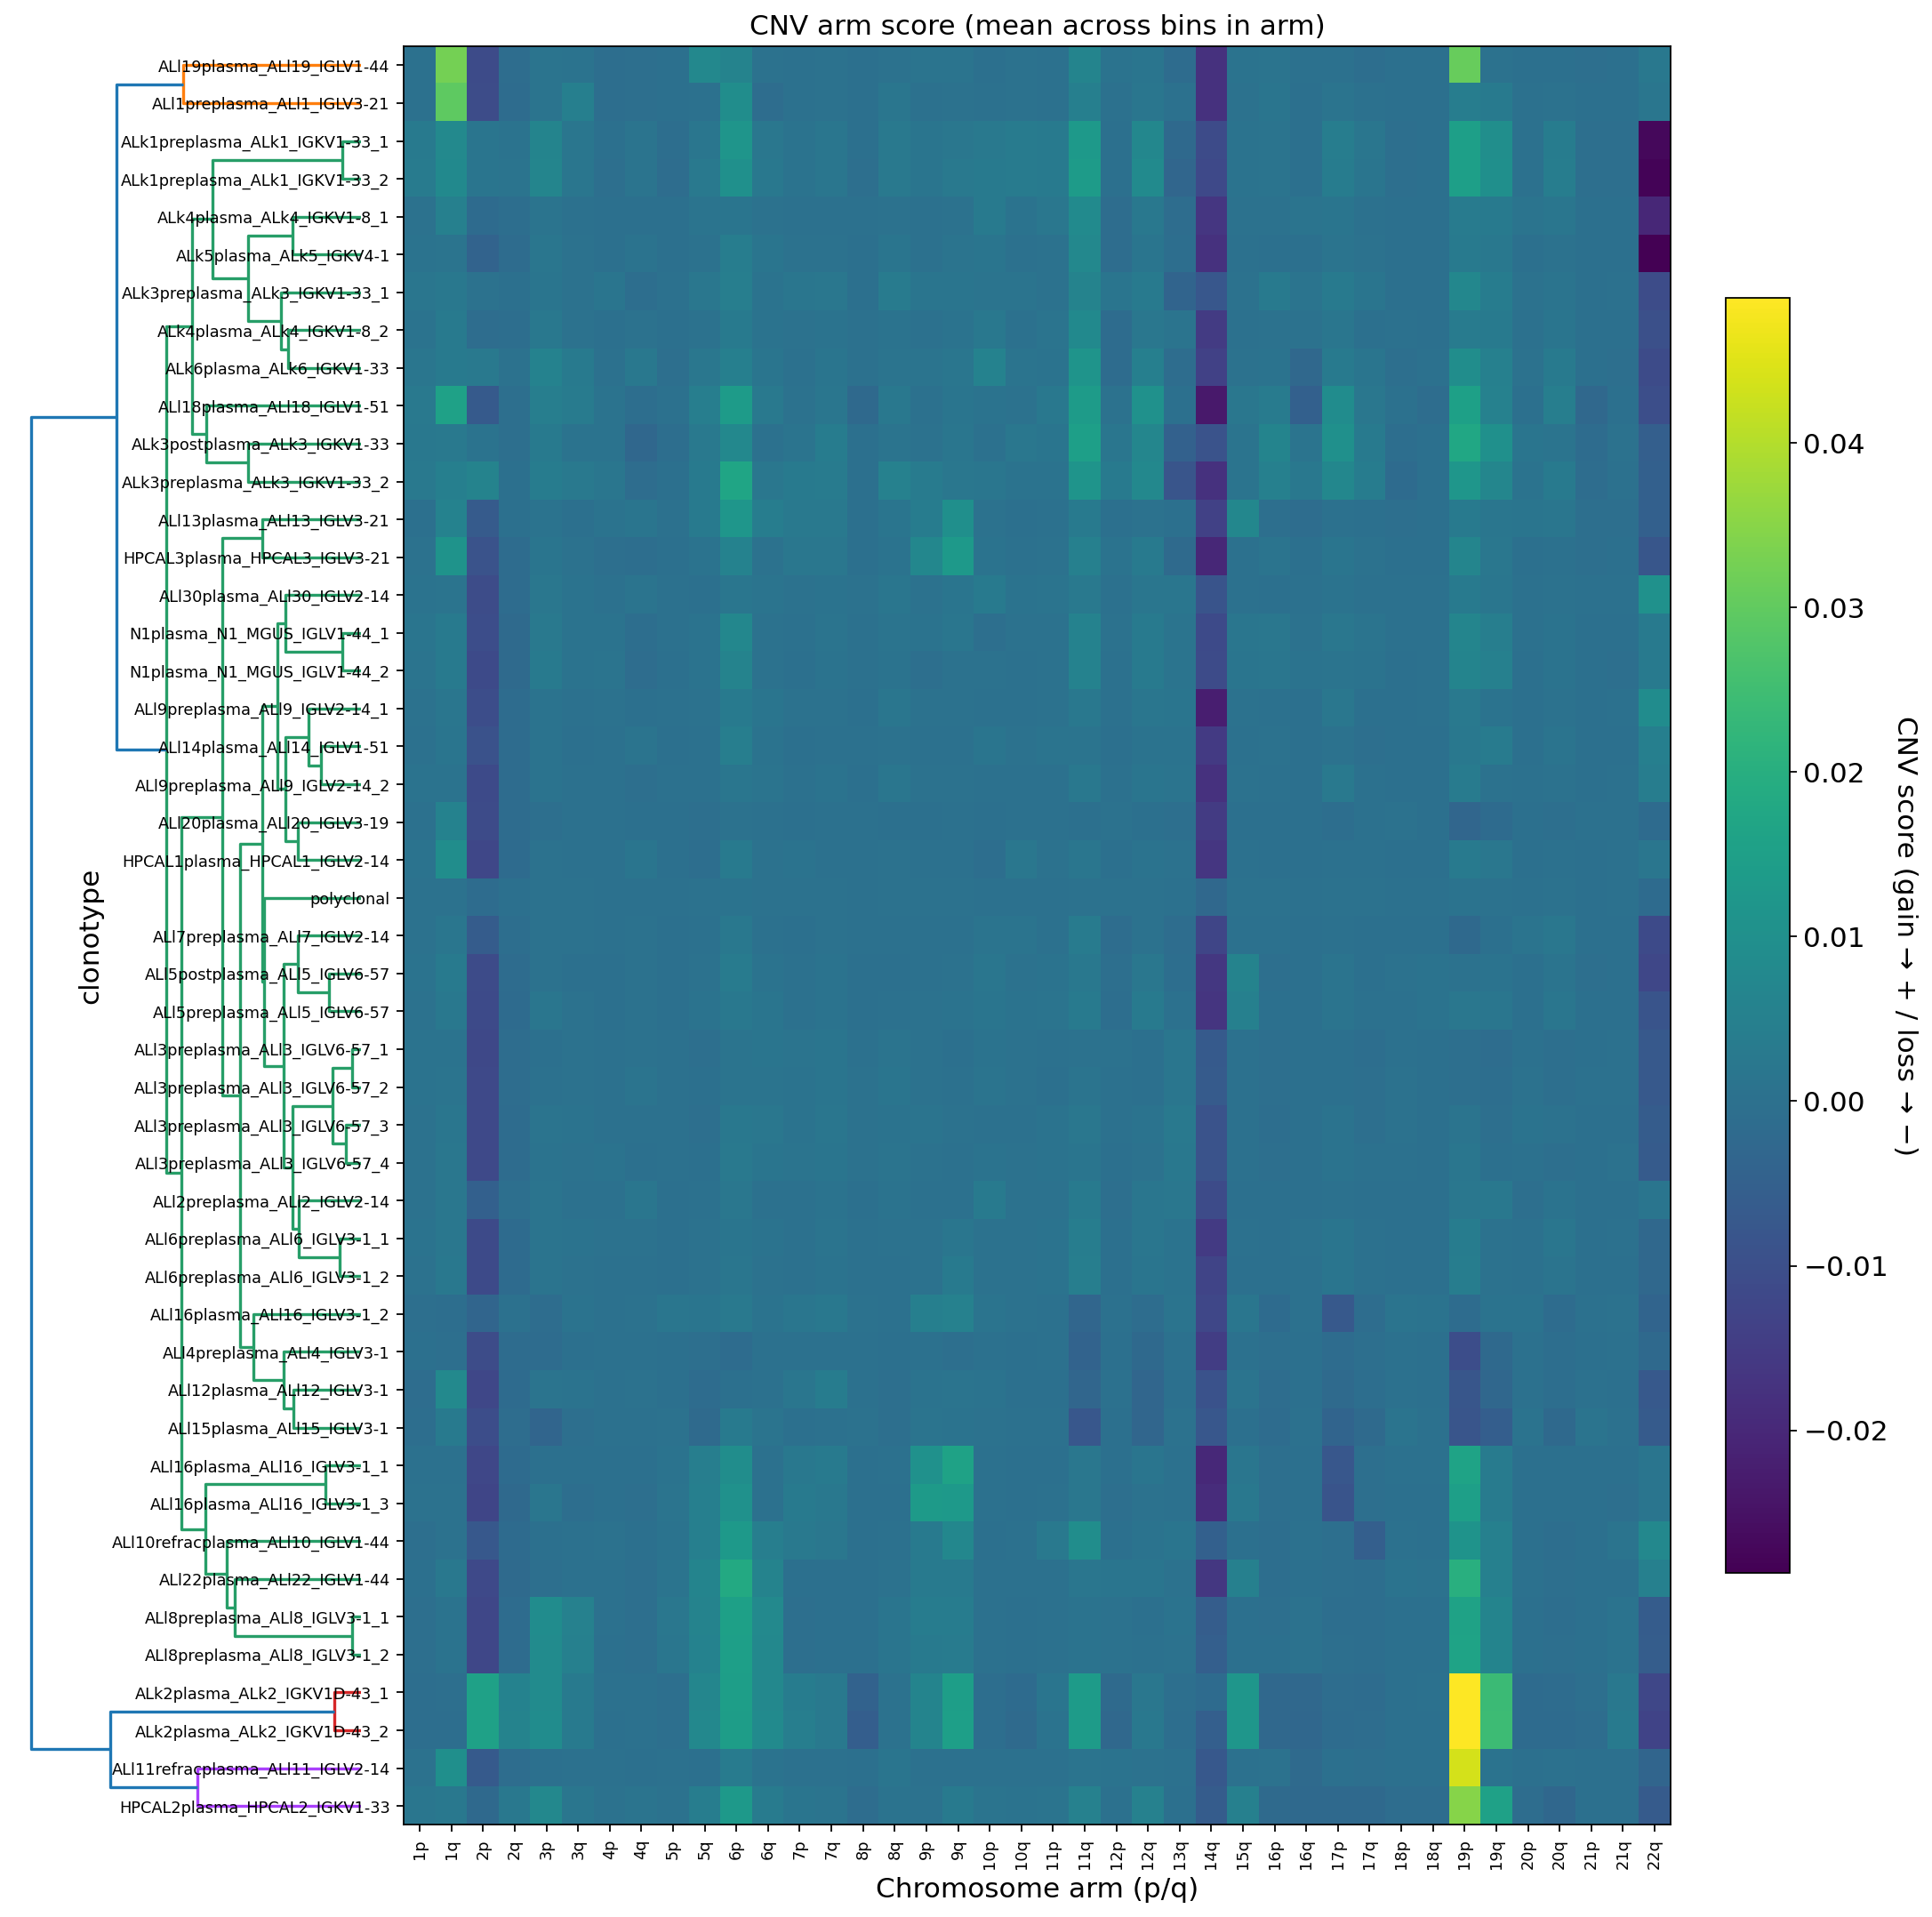

Saved heatmap with dendrogram: cnv_arm_heatmap.pdf


In [12]:
# 7) Heatmap with clustering and dendrogram
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
import matplotlib.gridspec as gridspec

ordered_arms = sorted(group_arm_df.columns, key=arm_sort_key)
plot_mat = group_arm_df[ordered_arms]

# hierarchical clustering on rows
Z = linkage(plot_mat.values, method="average", metric="euclidean")
row_order = leaves_list(Z)
plot_mat = plot_mat.iloc[row_order]

# layout with dendrogram on the left + heatmap on the right
fig = plt.figure(figsize=(max(6, plot_mat.shape[1]*0.35) + 2, max(4, plot_mat.shape[0]*0.35)))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 4], wspace=0.05)

# dendrogram
ax_dendro = fig.add_subplot(gs[0,0])
dendrogram(Z, orientation="left", no_labels=True, color_threshold=None)
ax_dendro.invert_yaxis()
ax_dendro.axis("off")

# heatmap
ax = fig.add_subplot(gs[0,1])
im = ax.imshow(plot_mat.values, aspect="auto", interpolation="nearest")

ax.set_yticks(np.arange(plot_mat.shape[0]))
ax.set_yticklabels(plot_mat.index, fontsize=8)
ax.set_xticks(np.arange(plot_mat.shape[1]))
ax.set_xticklabels(plot_mat.columns, rotation=90, fontsize=8)

ax.set_xlabel("Chromosome arm (p/q)")
ax.set_ylabel(GROUP_KEY)
ax.set_title("CNV arm score (mean across bins in arm)")
ax.grid(False)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("CNV score (gain → + / loss → −)", rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig(OUT_FIG, bbox_inches="tight")
plt.show()
print(f"Saved heatmap with dendrogram: {OUT_FIG}")


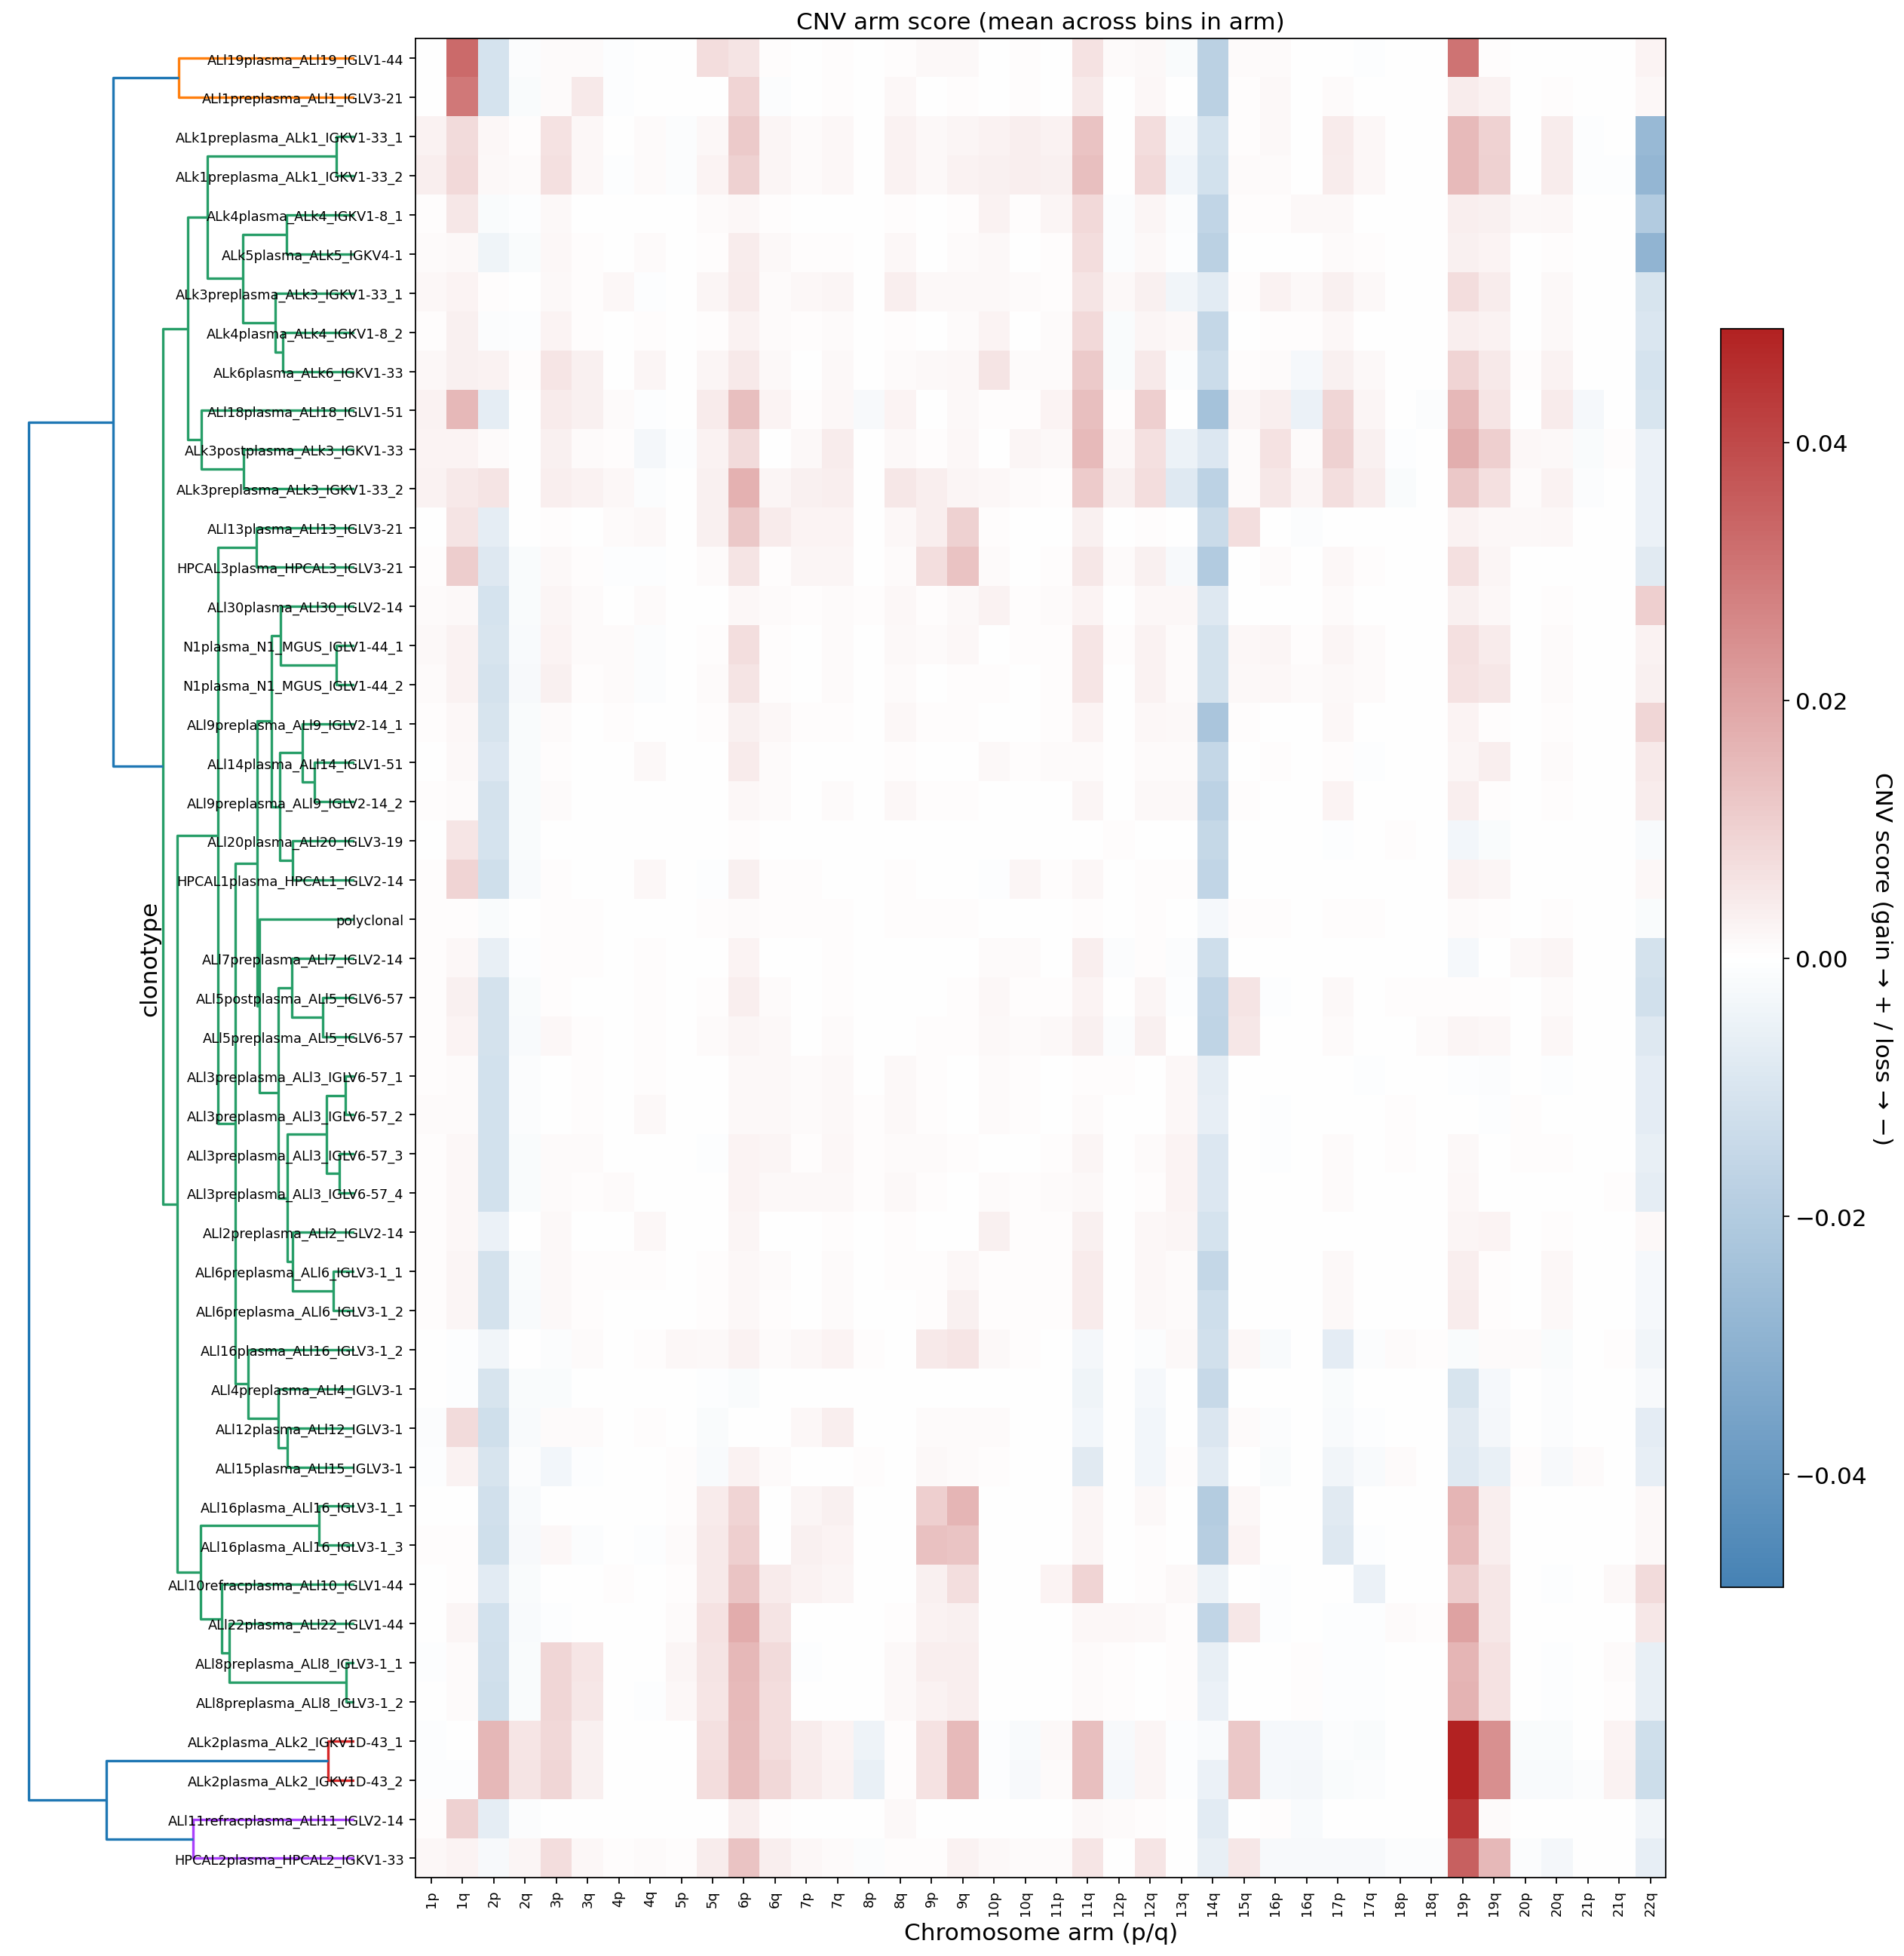

Saved heatmap with dendrogram: cnv_arm_heatmap.pdf


In [13]:
# 7) Heatmap with clustering and dendrogram (fixed spacing + custom colormap)
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# ---- order columns and build matrix ----
ordered_arms = sorted(group_arm_df.columns, key=arm_sort_key)
plot_mat = group_arm_df[ordered_arms]

# ---- hierarchical clustering on rows ----
Z = linkage(plot_mat.values, method="average", metric="euclidean")
row_order = leaves_list(Z)
plot_mat = plot_mat.iloc[row_order]

# ---- custom diverging colormap: steelblue (neg) - white - firebrick (pos) ----
cmap = LinearSegmentedColormap.from_list(
    "steelblue_white_firebrick",
    ["steelblue", "white", "firebrick"],
    N=256
)
# Center at 0 with symmetric limits
m = np.nanmax(np.abs(plot_mat.values))
norm = TwoSlopeNorm(vcenter=0.0, vmin=-m, vmax=+m)

# ---- layout: dendrogram (left) | spacer | heatmap (right) ----
# The small middle column creates clear separation so labels don't overlap
fig_h = max(4, plot_mat.shape[0]*0.35)
fig_w = max(6, plot_mat.shape[1]*0.35) + 2
fig = plt.figure(figsize=(fig_w, fig_h))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.0, 0.18, 4.0], wspace=0.0)

# Dendrogram
ax_dendro = fig.add_subplot(gs[0, 0])
dendrogram(Z, orientation="left", no_labels=True, color_threshold=None)
ax_dendro.invert_yaxis()
ax_dendro.axis("off")
# Nudge the dendrogram a tad left inside its own axes to buy extra space
ax_dendro.margins(x=1)

# Spacer axis (invisible, just to separate dendrogram from labels)
ax_gap = fig.add_subplot(gs[0, 1])
ax_gap.axis("off")

# Heatmap
ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(plot_mat.values, aspect="auto", interpolation="nearest", cmap=cmap, norm=norm)

ax.set_yticks(np.arange(plot_mat.shape[0]))
ax.set_yticklabels(plot_mat.index, fontsize=8)
ax.set_xticks(np.arange(plot_mat.shape[1]))
ax.set_xticklabels(plot_mat.columns, rotation=90, fontsize=8)

ax.set_xlabel("Chromosome arm (p/q)")
ax.set_ylabel(GROUP_KEY)
ax.set_title("CNV arm score (mean across bins in arm)")
ax.grid(False)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("CNV score (gain → + / loss → −)", rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig(OUT_FIG, bbox_inches="tight")
plt.show()
print(f"Saved heatmap with dendrogram: {OUT_FIG}")


## 4. Visualization and figure generation


In [14]:
# 7) Heatmap with clustering and dendrogram (fixed spacing + custom colormap)
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


# ====== Optional: restrict which rows (samples) appear ======
# Put your desired row names here (exact match to group_arm_df.index). 
# Leave as None or [] to include all rows.
SHOW_ROWS =["ALk3preplasma_ALk3_IGKV1-33_1","ALk3preplasma_ALk3_IGKV1-33_2","ALk3postplasma_ALk3_IGKV1-33","ALl5preplasma_ALl5_IGLV6-57","ALl5postplasma_ALl5_IGLV6-57",'ALl9preplasma_ALl9_IGLV2-14_1','ALl9preplasma_ALl9_IGLV2-14_2','polyclonal']

# If you want case-insensitive matching, set this to True
CASE_INSENSITIVE = False

# --- apply row filter ---
if SHOW_ROWS:
    if CASE_INSENSITIVE:
        # build a mapping from lowercase index -> original index
        idx_map = {str(i).lower(): i for i in group_arm_df.index}
        keep_idx = [idx_map[s.lower()] for s in SHOW_ROWS if s.lower() in idx_map]
    else:
        keep_idx = [s for s in SHOW_ROWS if s in group_arm_df.index]
    if not keep_idx:
        raise ValueError("None of SHOW_ROWS matched group_arm_df.index.")
    group_arm_df = group_arm_df.loc[keep_idx]
# ============================================================


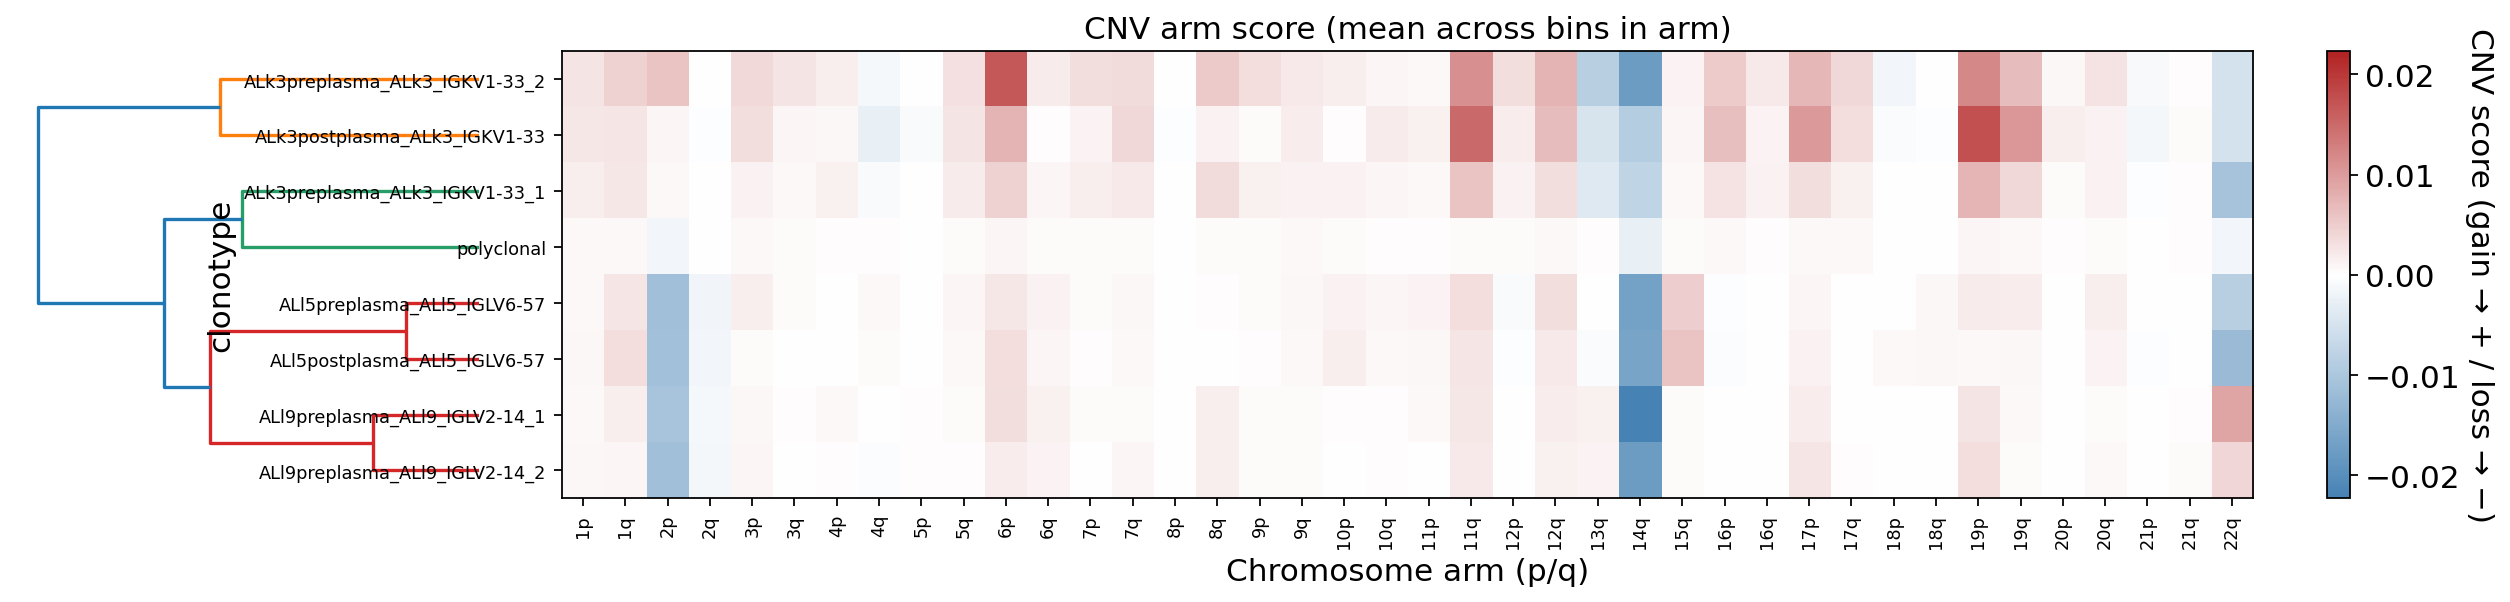

Saved heatmap with dendrogram: cnv_arm_heatmap.pdf


In [15]:
# ---- order columns and build matrix ----
ordered_arms = sorted(group_arm_df.columns, key=arm_sort_key)
plot_mat = group_arm_df[ordered_arms]

# ---- hierarchical clustering on rows ----
Z = linkage(plot_mat.values, method="average", metric="euclidean")
row_order = leaves_list(Z)
plot_mat = plot_mat.iloc[row_order]

# ---- custom diverging colormap: steelblue (neg) - white - firebrick (pos) ----
cmap = LinearSegmentedColormap.from_list(
    "steelblue_white_firebrick",
    ["steelblue", "white", "firebrick"],
    N=256
)
# Center at 0 with symmetric limits
m = np.nanmax(np.abs(plot_mat.values))
norm = TwoSlopeNorm(vcenter=0.0, vmin=-m, vmax=+m)

# ---- layout: dendrogram (left) | spacer | heatmap (right) ----
# The small middle column creates clear separation so labels don't overlap
fig_h = max(4, plot_mat.shape[0]*0.35)
fig_w = max(6, plot_mat.shape[1]*0.35) + 2
fig = plt.figure(figsize=(fig_w, fig_h))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.0, 0.18, 4.0], wspace=0.0)

# Dendrogram
ax_dendro = fig.add_subplot(gs[0, 0])
dendrogram(Z, orientation="left", no_labels=True, color_threshold=None)
ax_dendro.invert_yaxis()
ax_dendro.axis("off")
# Nudge the dendrogram a tad left inside its own axes to buy extra space
ax_dendro.margins(x=1)

# Spacer axis (invisible, just to separate dendrogram from labels)
ax_gap = fig.add_subplot(gs[0, 1])
ax_gap.axis("off")

# Heatmap
ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(plot_mat.values, aspect="auto", interpolation="nearest", cmap=cmap, norm=norm)

ax.set_yticks(np.arange(plot_mat.shape[0]))
ax.set_yticklabels(plot_mat.index, fontsize=8)
ax.set_xticks(np.arange(plot_mat.shape[1]))
ax.set_xticklabels(plot_mat.columns, rotation=90, fontsize=8)

ax.set_xlabel("Chromosome arm (p/q)")
ax.set_ylabel(GROUP_KEY)
ax.set_title("CNV arm score (mean across bins in arm)")
ax.grid(False)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("CNV score (gain → + / loss → −)", rotation=270, labelpad=15)

plt.tight_layout()
plt.savefig(OUT_FIG, bbox_inches="tight")
plt.show()
print(f"Saved heatmap with dendrogram: {OUT_FIG}")


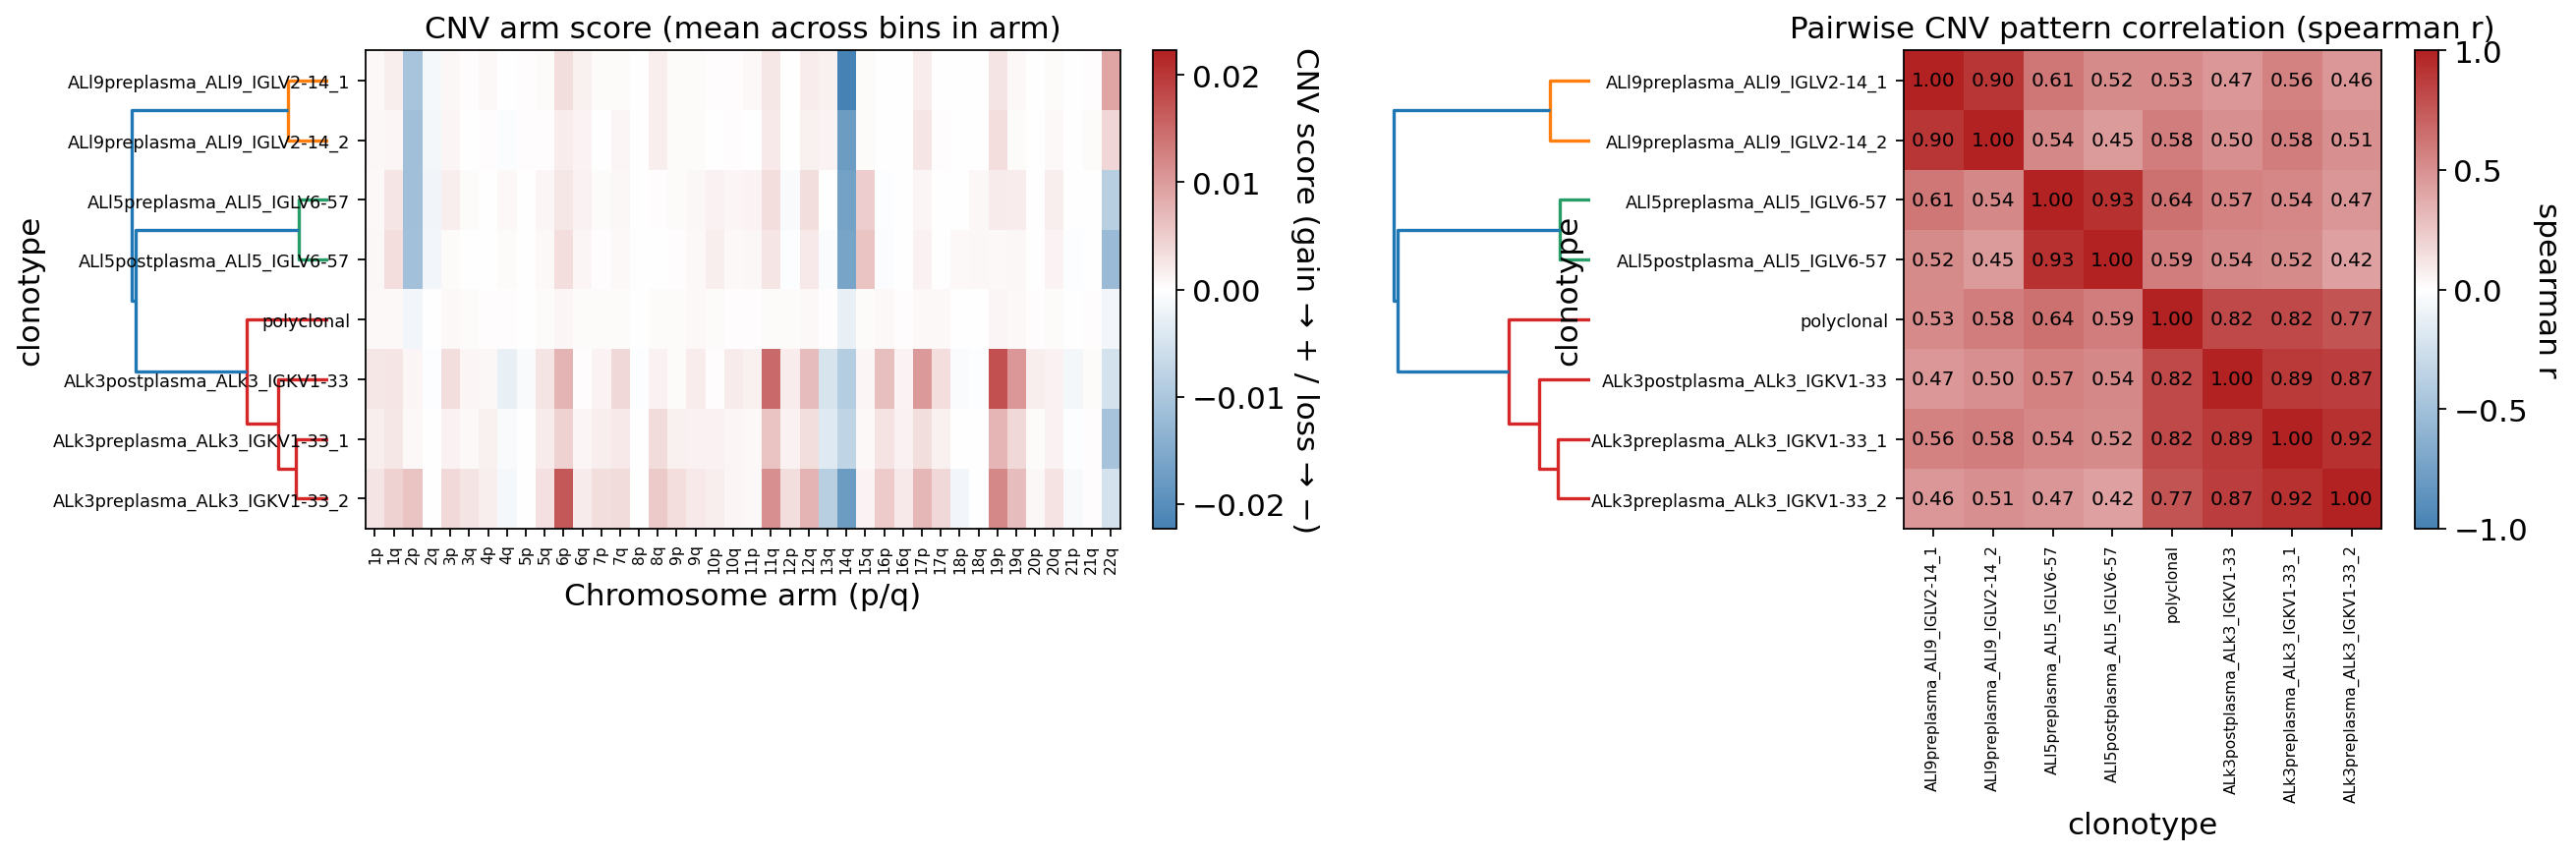

Saved joint CNV + correlation figure: cnv_arm_heatmap.pdf


In [23]:
# CNV heatmap + (row–row) correlation heatmap side-by-side (both with dendrograms)
# - clusters rows using correlation distance (1 - spearman r)
# - annotates correlation values as text
# - saves a single combined PDF

from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# =========================
# USER SETTINGS (expects these already exist in your notebook/script)
# =========================
# group_arm_df : pd.DataFrame (rows = groups/clusters, cols = chromosome arms)
# arm_sort_key : function for sorting arms
# GROUP_KEY    : string for y-axis label (e.g., "cluster" or "group")
# OUT_FIG      : output pdf path (e.g., "cnv_heatmap.pdf")

# =========================
# 0) Order columns and build matrix
# =========================
ordered_arms = sorted(group_arm_df.columns, key=arm_sort_key)
plot_mat0 = group_arm_df[ordered_arms].copy()

# =========================
# 1) Row-wise correlation matrix (spearman across arms)
# =========================
corr_mat0 = plot_mat0.T.corr(method="spearman")  # rows x rows

# =========================
# 2) Cluster rows using correlation distance: d = 1 - r
# =========================
corr_dist = 1.0 - corr_mat0.values
np.fill_diagonal(corr_dist, 0.0)

Z = linkage(squareform(corr_dist, checks=False), method="average")
row_order = leaves_list(Z)

plot_mat = plot_mat0.iloc[row_order]
corr_mat = corr_mat0.iloc[row_order, row_order]

# =========================
# 3) Colormaps / norms
# =========================
# CNV diverging cmap: steelblue - white - firebrick
cmap_cnv = LinearSegmentedColormap.from_list(
    "steelblue_white_firebrick",
    ["steelblue", "white", "firebrick"],
    N=256
)
m = np.nanmax(np.abs(plot_mat.values))
m = 1.0 if (m is None or not np.isfinite(m) or m == 0) else m
norm_cnv = TwoSlopeNorm(vcenter=0.0, vmin=-m, vmax=+m)

# Correlation cmap can reuse the same (nice diverging), fixed limits [-1, 1]
cmap_corr = cmap_cnv
norm_corr = TwoSlopeNorm(vcenter=0.0, vmin=-1.0, vmax=1.0)

# =========================
# 4) Figure layout: two panels side-by-side, each has [dendro | gap | heatmap]
# =========================
n_rows = plot_mat.shape[0]
n_cols = plot_mat.shape[1]

fig_h = max(4, n_rows * 0.35)
fig_w_left = max(6, n_cols * 0.25) + 2.0      # CNV panel width heuristic
fig_w_right = max(4, n_rows * 0.25) + 2.0     # Corr panel width heuristic
fig_w = fig_w_left + fig_w_right + 1.0

fig = plt.figure(figsize=(fig_w, fig_h))
outer = gridspec.GridSpec(1, 2, width_ratios=[1.0, 1.0], wspace=0.18)

# ---- Left panel: CNV heatmap + dendrogram ----
gsL = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=outer[0],
    width_ratios=[1.0, 0.18, 4.0], wspace=0.0
)

axL_d = fig.add_subplot(gsL[0, 0])
dendrogram(Z, orientation="left", no_labels=True, color_threshold=None)
axL_d.invert_yaxis()
axL_d.axis("off")

axL_gap = fig.add_subplot(gsL[0, 1])
axL_gap.axis("off")

axL = fig.add_subplot(gsL[0, 2])
imL = axL.imshow(plot_mat.values, aspect="auto", interpolation="nearest",
                 cmap=cmap_cnv, norm=norm_cnv)

axL.set_yticks(np.arange(n_rows))
axL.set_yticklabels(plot_mat.index, fontsize=8)
axL.set_xticks(np.arange(n_cols))
axL.set_xticklabels(plot_mat.columns, rotation=90, fontsize=7)

axL.set_xlabel("Chromosome arm (p/q)")
axL.set_ylabel(GROUP_KEY)
axL.set_title("CNV arm score (mean across bins in arm)")
axL.grid(False)

cbarL = plt.colorbar(imL, ax=axL, fraction=0.046, pad=0.04)
cbarL.ax.set_ylabel("CNV score (gain → + / loss → −)", rotation=270, labelpad=15)

# ---- Right panel: Correlation heatmap + dendrogram + text annotations ----
gsR = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=outer[1],
    width_ratios=[1.0, 0.18, 4.0], wspace=0.0
)

axR_d = fig.add_subplot(gsR[0, 0])
dendrogram(Z, orientation="left", no_labels=True, color_threshold=None)
axR_d.invert_yaxis()
axR_d.axis("off")

axR_gap = fig.add_subplot(gsR[0, 1])
axR_gap.axis("off")

axR = fig.add_subplot(gsR[0, 2])
# Correlation heatmap (square)
imR = axR.imshow(
    corr_mat.values,
    interpolation="nearest",
    cmap=cmap_corr,
    norm=norm_corr,
    aspect="equal"   # <- each cell is square
)

# Make the axes box itself square (robust across layouts)
axR.set_box_aspect(1)  # matplotlib >= 3.3

axR.set_xticks(np.arange(n_rows))
axR.set_yticks(np.arange(n_rows))
axR.set_xticklabels(corr_mat.columns, rotation=90, fontsize=7)
axR.set_yticklabels(corr_mat.index, fontsize=8)

axR.set_xlabel(GROUP_KEY)
axR.set_ylabel(GROUP_KEY)
axR.set_title("Pairwise CNV pattern correlation (spearman r)")
axR.grid(False)

cbarR = plt.colorbar(imR, ax=axR, fraction=0.046, pad=0.04)
cbarR.ax.set_ylabel("spearman r", rotation=270, labelpad=15)

# ---- Add correlation values as text ----
# Auto font size so it doesn't become unreadable for large matrices
# (If n_rows is big, consider turning this off or annotating only upper triangle.)
if n_rows <= 40:
    # heuristic: smaller text for bigger matrices
    txt_fs = max(4, 10 - int(n_rows / 5))
    vals = corr_mat.values
    for i in range(n_rows):
        for j in range(n_rows):
            axR.text(
                j, i, f"{vals[i, j]:.2f}",
                ha="center", va="center",
                fontsize=txt_fs
            )

# =========================
# 5) Save
# =========================
plt.tight_layout()
plt.savefig(OUT_FIG, bbox_inches="tight")
plt.show()
print(f"Saved joint CNV + correlation figure: {OUT_FIG}")
